# Actigraph Database Analysis Notebook

This notebook provides comprehensive access to the Actigraph_record.db database with examples for each table in DataFrame format. It's designed to be a foundation for adding graphs and visualizations that can later be integrated into the main application.

## Database Structure
- **analysis_records**: Main analysis metadata (ID, description, date, etc.)
- **sleep_analysis**: Sleep-related analysis results
- **activity_analysis**: Activity-related analysis results  
- **light_analysis**: Light-related analysis results

## Usage Guide
1. Run each cell sequentially
2. Modify analysis_id variables to explore different records
3. Add your visualization code in the designated sections
4. Test your graphs before integrating into the main app

## 1. Import Required Libraries

In [1]:
# Core libraries for database access and data manipulation
import sqlite3
import pandas as pd
import numpy as np
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries (ready for future graph integration)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Custom database module
import sys
import os
sys.path.append('/Users/arahjou/Documents/APP_CIRCADIAN_MEDICINE')
from tools.database import ActigraphDB

# Configure plotting style
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ All libraries imported successfully!")
print(f"📅 Notebook run date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Notebook run date: 2025-09-22 13:02:43


## 2. Establish Database Connection

In [2]:
# Initialize database connection
db_path = "Actigraph_record.db"
db = ActigraphDB(db_path)

# Direct SQLite connection for DataFrame operations
conn = sqlite3.connect(db_path)

# Test connection and show database info
try:
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    
    print("🔗 Database connection established successfully!")
    print(f"📁 Database path: {os.path.abspath(db_path)}")
    print(f"📊 Number of tables: {len(tables)}")
    print("✅ Ready for data analysis!")
    
except Exception as e:
    print(f"❌ Database connection error: {e}")
    print("💡 Make sure you have run some analyses first to create the database.")

🔗 Database connection established successfully!
📁 Database path: /Users/arahjou/Documents/APP_CIRCADIAN_MEDICINE/Actigraph_record.db
📊 Number of tables: 4
✅ Ready for data analysis!


## 3. List Available Tables and Records

In [3]:
# Get all table names and their structure
def show_database_structure():
    cursor = conn.cursor()
    
    # Get all tables
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [table[0] for table in cursor.fetchall()]
    
    print("📋 DATABASE STRUCTURE")
    print("=" * 50)
    
    for table in tables:
        # Get table info
        cursor.execute(f"PRAGMA table_info({table})")
        columns = cursor.fetchall()
        
        # Get row count
        cursor.execute(f"SELECT COUNT(*) FROM {table}")
        row_count = cursor.fetchone()[0]
        
        print(f"\n📊 Table: {table}")
        print(f"   Records: {row_count}")
        print("   Columns:")
        for col in columns:
            print(f"     • {col[1]} ({col[2]})")
    
    return tables

# Show database structure
available_tables = show_database_structure()

# Get all analysis records for reference
print("\n\n🔍 AVAILABLE ANALYSIS RECORDS")
print("=" * 50)

records = db.get_all_records()
if records:
    for record in records:
        print(f"🔹 ID: {record['id']}")
        print(f"   Description: {record['description']}")
        print(f"   Date: {record['date']}")
        print(f"   File: {record['file_name']}")
        
        # Count analysis results
        sleep_count = len(db.get_analysis_results(record['id'], 'sleep_analysis'))
        activity_count = len(db.get_analysis_results(record['id'], 'activity_analysis'))
        light_count = len(db.get_analysis_results(record['id'], 'light_analysis'))
        
        print(f"   Analyses: {sleep_count} sleep, {activity_count} activity, {light_count} light")
        print()
else:
    print("❌ No analysis records found.")
    print("💡 Run some analyses in the main app first.")

📋 DATABASE STRUCTURE

📊 Table: analysis_records
   Records: 2
   Columns:
     • id (TEXT)
     • description (TEXT)
     • date (TEXT)
     • created_at (TEXT)
     • file_name (TEXT)
     • selected_dates (TEXT)

📊 Table: sleep_analysis
   Records: 6
   Columns:
     • record_id (TEXT)
     • analysis_type (TEXT)
     • results (TEXT)

📊 Table: activity_analysis
   Records: 8
   Columns:
     • record_id (TEXT)
     • analysis_type (TEXT)
     • results (TEXT)

📊 Table: light_analysis
   Records: 8
   Columns:
     • record_id (TEXT)
     • analysis_type (TEXT)
     • results (TEXT)


🔍 AVAILABLE ANALYSIS RECORDS
🔹 ID: 000002
   Description: Test2
   Date: 2025-09-21 08:16:06
   File: Test01_wrist.txt
   Analyses: 3 sleep, 4 activity, 4 light

🔹 ID: 00001
   Description: Test_run_1
   Date: 2025-09-21 08:04:36
   File: Test01_wrist.txt
   Analyses: 3 sleep, 4 activity, 4 light



## 4. Access Analysis Records Table as DataFrame

The main table containing metadata for all analysis records.

In [4]:
# Example 1: Load analysis_records table as DataFrame
def get_analysis_records_df():
    """Load the main analysis records table as a pandas DataFrame"""
    query = """
    SELECT 
        id,
        description,
        date,
        created_at,
        file_name,
        selected_dates
    FROM analysis_records
    ORDER BY created_at DESC
    """
    
    df = pd.read_sql_query(query, conn)
    
    # Parse selected_dates JSON column
    if not df.empty and 'selected_dates' in df.columns:
        df['selected_dates_parsed'] = df['selected_dates'].apply(
            lambda x: json.loads(x) if x and x != 'null' else []
        )
        df['num_dates'] = df['selected_dates_parsed'].apply(len)
    
    return df

# Load and display the analysis records
print("📊 ANALYSIS RECORDS TABLE")
print("=" * 50)

analysis_records_df = get_analysis_records_df()

if not analysis_records_df.empty:
    print(f"Shape: {analysis_records_df.shape}")
    print("\nDataFrame Info:")
    print(analysis_records_df.info())
    
    print("\nFirst few records:")
    display(analysis_records_df.head())
    
    print("\nSummary statistics:")
    print(f"• Total records: {len(analysis_records_df)}")
    print(f"• Date range: {analysis_records_df['date'].min()} to {analysis_records_df['date'].max()}")
    if 'num_dates' in analysis_records_df.columns:
        print(f"• Average dates per analysis: {analysis_records_df['num_dates'].mean():.1f}")
    
    # Store for later use
    print("\n✅ analysis_records_df is ready for visualization!")
else:
    print("❌ No records found in analysis_records table")
    analysis_records_df = pd.DataFrame()  # Empty DataFrame

📊 ANALYSIS RECORDS TABLE
Shape: (2, 8)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2 non-null      object
 1   description            2 non-null      object
 2   date                   2 non-null      object
 3   created_at             2 non-null      object
 4   file_name              2 non-null      object
 5   selected_dates         2 non-null      object
 6   selected_dates_parsed  2 non-null      object
 7   num_dates              2 non-null      int64 
dtypes: int64(1), object(7)
memory usage: 260.0+ bytes
None

First few records:


,id,description,date,created_at,file_name,selected_dates,selected_dates_parsed,num_dates
0,000002,Test2,2025-09-21 08:16:06,2025-09-21 08:16:06,Test01_wrist.txt,"[""2024-01-16"", ""2024-01-17"", ""2024-01-18""]","[2024-01-16, 2024-01-17, 2024-01-18]",3
1,00001,Test_run_1,2025-09-21 08:04:36,2025-09-21 08:04:36,Test01_wrist.txt,"[""2024-01-15"", ""2024-01-16"", ""2024-01-17"", ""20...","[2024-01-15, 2024-01-16, 2024-01-17, 2024-01-18]",4



Summary statistics:
• Total records: 2
• Date range: 2025-09-21 08:04:36 to 2025-09-21 08:16:06
• Average dates per analysis: 3.5

✅ analysis_records_df is ready for visualization!


## 5. Access Sleep Analysis Results as DataFrames

Sleep analysis results for a specific record, with examples for each analysis type.

In [5]:
# Example 2: Load sleep analysis results as DataFrames
def get_sleep_analysis_df(analysis_id=None):
    """Load sleep analysis results for a specific record"""
    if analysis_id is None:
        # Get the most recent record ID
        if not analysis_records_df.empty:
            analysis_id = analysis_records_df.iloc[0]['id']
        else:
            print("❌ No analysis records available")
            return {}
    
    print(f"🛌 SLEEP ANALYSIS RESULTS FOR: {analysis_id}")
    print("=" * 50)
    
    sleep_results = db.get_analysis_results(analysis_id, 'sleep_analysis')
    sleep_dataframes = {}
    
    for result in sleep_results:
        analysis_type = result['analysis_type']
        print(f"\n📊 {analysis_type}")
        print("-" * 30)
        
        try:
            # Convert JSON results to DataFrame
            if isinstance(result['results'], list) and len(result['results']) > 0:
                df = pd.DataFrame(result['results'])
                sleep_dataframes[analysis_type] = df
                
                print(f"Shape: {df.shape}")
                print("Columns:", list(df.columns))
                print("Preview:")
                display(df.head())
                
            elif isinstance(result['results'], dict):
                df = pd.DataFrame([result['results']])
                sleep_dataframes[analysis_type] = df
                
                print(f"Shape: {df.shape}")
                print("Data:")
                display(df)
                
            else:
                print(f"Raw result: {result['results']}")
                
        except Exception as e:
            print(f"❌ Error processing {analysis_type}: {e}")
            print(f"Raw data: {result['results']}")
    
    return sleep_dataframes

# Load sleep analysis data
# Change this to your specific analysis ID or leave None for most recent
TARGET_ANALYSIS_ID = None  # e.g., "000002" or None for latest

sleep_dfs = get_sleep_analysis_df(TARGET_ANALYSIS_ID)

print(f"\n✅ Loaded {len(sleep_dfs)} sleep analysis DataFrames!")
for name in sleep_dfs.keys():
    print(f"   • {name}: sleep_dfs['{name}']")

🛌 SLEEP ANALYSIS RESULTS FOR: 000002

📊 sleep_periods
------------------------------
Shape: (3, 6)
Columns: ['Sleep_onset_DATE', 'Sleep_onset_Time', 'Sleep_offset_DATE', 'Sleep_offset_TIME', 'mid_sleep_DATE', 'Mid_sleep_Time']
Preview:


,Sleep_onset_DATE,Sleep_onset_Time,Sleep_offset_DATE,Sleep_offset_TIME,mid_sleep_DATE,Mid_sleep_Time
0,2024-01-16T00:00:00.000,01:39:39,2024-01-16T00:00:00.000,09:37:39,2024-01-16T00:00:00.000,05:38:39
1,2024-01-17T00:00:00.000,02:54:39,2024-01-17T00:00:00.000,08:42:39,2024-01-17T00:00:00.000,05:48:39
2,2024-01-17T00:00:00.000,23:29:39,2024-01-18T00:00:00.000,09:20:39,2024-01-18T00:00:00.000,04:25:09



📊 cpd_mid_sleep
------------------------------
Shape: (3, 11)
Columns: ['Sleep_onset_DATE', 'Sleep_onset_Time', 'Sleep_offset_DATE', 'Sleep_offset_TIME', 'mid_sleep_DATE', 'Mid_sleep_Time', 'mid_sleep_dt', 'midpoint_hours_centered', 'cpd_hours', 'mean_midpoint_hours', 'median_midpoint_hours']
Preview:


,Sleep_onset_DATE,Sleep_onset_Time,Sleep_offset_DATE,Sleep_offset_TIME,mid_sleep_DATE,Mid_sleep_Time,mid_sleep_dt,midpoint_hours_centered,cpd_hours,mean_midpoint_hours,median_midpoint_hours
0,2024-01-16T00:00:00.000,01:39:39,2024-01-16T00:00:00.000,09:37:39,2024-01-16T00:00:00.000,05:38:39,2024-01-16T05:38:39.000,-6.355833,NaN,-6.706767,-6.355833
1,2024-01-17T00:00:00.000,02:54:39,2024-01-17T00:00:00.000,08:42:39,2024-01-17T00:00:00.000,05:48:39,2024-01-17T05:48:39.000,-6.189167,0.543772,-6.706767,-6.355833
2,2024-01-17T00:00:00.000,23:29:39,2024-01-18T00:00:00.000,09:20:39,2024-01-18T00:00:00.000,04:25:09,2024-01-18T04:25:09.000,-7.580833,1.643389,-6.706767,-6.355833



📊 sri_sleep
------------------------------
Shape: (2, 4)
Columns: ['start_date', 'end_date', 'SRI', 'valid_epochs_pct']
Preview:


,start_date,end_date,SRI,valid_epochs_pct
0,2024-01-17T00:00:00.000,2024-01-18T00:00:00.000,68.750000,100.000
1,2024-01-16T00:00:00.000,2024-01-17T00:00:00.000,79.716629,93.125



✅ Loaded 3 sleep analysis DataFrames!
   • sleep_periods: sleep_dfs['sleep_periods']
   • cpd_mid_sleep: sleep_dfs['cpd_mid_sleep']
   • sri_sleep: sleep_dfs['sri_sleep']


In [14]:
sleep_dfs.keys()

dict_keys(['sleep_periods', 'cpd_mid_sleep', 'sri_sleep'])

In [18]:
sleep_dfs['sleep_periods']

,Sleep_onset_DATE,Sleep_onset_Time,Sleep_offset_DATE,Sleep_offset_TIME,mid_sleep_DATE,Mid_sleep_Time
0,2024-01-16T00:00:00.000,01:39:39,2024-01-16T00:00:00.000,09:37:39,2024-01-16T00:00:00.000,05:38:39
1,2024-01-17T00:00:00.000,02:54:39,2024-01-17T00:00:00.000,08:42:39,2024-01-17T00:00:00.000,05:48:39
2,2024-01-17T00:00:00.000,23:29:39,2024-01-18T00:00:00.000,09:20:39,2024-01-18T00:00:00.000,04:25:09


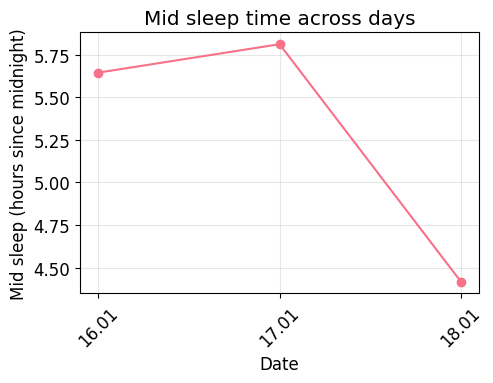

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import NullLocator

df = sleep_dfs['sleep_periods'][['mid_sleep_DATE', 'Mid_sleep_Time']].copy()

# Normalize to midnight so they’re clean datetime dates
df["mid_sleep_DATE"] = pd.to_datetime(df["mid_sleep_DATE"]).dt.normalize()
# Convert time to timedelta, then to hours
df["mid_sleep_hours"] = pd.to_timedelta(df["Mid_sleep_Time"]).dt.total_seconds() / 3600
fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
ax.plot(df["mid_sleep_DATE"], df["mid_sleep_hours"], marker="o")
ax.set_ylabel("Mid sleep (hours since midnight)")
ax.set_xlabel("Date")
ax.set_title("Mid sleep time across days")

# ✅ One tick per day, formatted as DD.MM
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))

# remove minor ticks
ax.xaxis.set_minor_locator(NullLocator())

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# average of df["mid_sleep_hours"] = pd.to_timedelta(df["Mid_sleep_Time"]).dt.total_seconds() / 3600
# SD of df["mid_sleep_hours"] = pd.to_timedelta(df["Mid_sleep_Time"]).dt.total_seconds() / 3600

In [54]:
sleep_dfs['cpd_mid_sleep']

,Sleep_onset_DATE,Sleep_onset_Time,Sleep_offset_DATE,Sleep_offset_TIME,mid_sleep_DATE,Mid_sleep_Time,mid_sleep_dt,midpoint_hours_centered,cpd_hours,mean_midpoint_hours,median_midpoint_hours
0,2024-01-16T00:00:00.000,01:39:39,2024-01-16T00:00:00.000,09:37:39,2024-01-16T00:00:00.000,05:38:39,2024-01-16T05:38:39.000,-6.355833,NaN,-6.706767,-6.355833
1,2024-01-17T00:00:00.000,02:54:39,2024-01-17T00:00:00.000,08:42:39,2024-01-17T00:00:00.000,05:48:39,2024-01-17T05:48:39.000,-6.189167,0.543772,-6.706767,-6.355833
2,2024-01-17T00:00:00.000,23:29:39,2024-01-18T00:00:00.000,09:20:39,2024-01-18T00:00:00.000,04:25:09,2024-01-18T04:25:09.000,-7.580833,1.643389,-6.706767,-6.355833


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import NullLocator

df = sleep_dfs['sleep_periods'][['mid_sleep_DATE', 'Mid_sleep_Time']].copy()

# Normalize to midnight so they’re clean datetime dates
df["mid_sleep_DATE"] = pd.to_datetime(df["mid_sleep_DATE"]).dt.normalize()
# Convert time to timedelta, then to hours
df["mid_sleep_hours"] = pd.to_timedelta(df["Mid_sleep_Time"]).dt.total_seconds() / 3600
fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
ax.plot(df["mid_sleep_DATE"], df["mid_sleep_hours"], marker="o")
ax.set_ylabel("Mid sleep (hours since midnight)")
ax.set_xlabel("Date")
ax.set_title("Mid sleep time across days")

# ✅ One tick per day, formatted as DD.MM
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))

# remove minor ticks
ax.xaxis.set_minor_locator(NullLocator())

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Access Activity Analysis Results as DataFrames

Activity analysis results including IS/IV, L5/M10/RA, cosinor, and CPD analyses.

In [6]:
# Example 3: Load activity analysis results as DataFrames
def get_activity_analysis_df(analysis_id=None):
    """Load activity analysis results for a specific record"""
    if analysis_id is None:
        if not analysis_records_df.empty:
            analysis_id = analysis_records_df.iloc[0]['id']
        else:
            print("❌ No analysis records available")
            return {}
    
    print(f"🏃 ACTIVITY ANALYSIS RESULTS FOR: {analysis_id}")
    print("=" * 50)
    
    activity_results = db.get_analysis_results(analysis_id, 'activity_analysis')
    activity_dataframes = {}
    
    for result in activity_results:
        analysis_type = result['analysis_type']
        print(f"\n📊 {analysis_type}")
        print("-" * 30)
        
        try:
            if isinstance(result['results'], list) and len(result['results']) > 0:
                df = pd.DataFrame(result['results'])
                activity_dataframes[analysis_type] = df
                
                print(f"Shape: {df.shape}")
                print("Columns:", list(df.columns))
                print("Preview:")
                display(df.head())
                
            elif isinstance(result['results'], dict):
                df = pd.DataFrame([result['results']])
                activity_dataframes[analysis_type] = df
                
                print(f"Shape: {df.shape}")
                print("Data:")
                display(df)
                
            else:
                print(f"Raw result: {result['results']}")
                
        except Exception as e:
            print(f"❌ Error processing {analysis_type}: {e}")
            print(f"Raw data: {result['results']}")
    
    return activity_dataframes

# Load activity analysis data
activity_dfs = get_activity_analysis_df(TARGET_ANALYSIS_ID)

print(f"\n✅ Loaded {len(activity_dfs)} activity analysis DataFrames!")
for name in activity_dfs.keys():
    print(f"   • {name}: activity_dfs['{name}']")

🏃 ACTIVITY ANALYSIS RESULTS FOR: 000002

📊 activity_is_iv
------------------------------
Shape: (3, 6)
Columns: ['day_pair', 'start_date', 'end_date', 'IS_2day', 'IV_2day', 'n_minutes']
Preview:


,day_pair,start_date,end_date,IS_2day,IV_2day,n_minutes
0,2024-01-15 to 2024-01-16,2024-01-15T00:00:00.000,2024-01-16T00:00:00.000,0.523935,0.355038,2160
1,2024-01-16 to 2024-01-17,2024-01-16T00:00:00.000,2024-01-17T00:00:00.000,0.237670,0.410866,2880
2,2024-01-17 to 2024-01-18,2024-01-17T00:00:00.000,2024-01-18T00:00:00.000,0.261499,0.522293,2160



📊 activity_l5_m10_ra
------------------------------
Shape: (4, 6)
Columns: ['date', 'M10_start', 'M10_mean', 'L5_start', 'L5_mean', 'RA']
Preview:


,date,M10_start,M10_mean,L5_start,L5_mean,RA
0,2024-01-15T00:00:00.000,2024-01-16T01:29:39.000Z,16.134724,2024-01-15T23:29:39.000Z,0.000000,1.000000
1,2024-01-16T00:00:00.000,2024-01-16T12:47:39.000Z,82.964759,2024-01-17T01:22:39.000Z,1.900779,0.955205
2,2024-01-17T00:00:00.000,2024-01-18T08:32:39.000Z,51.218167,2024-01-17T23:19:39.000Z,2.175278,0.918519
3,2024-01-18T00:00:00.000,2024-01-18T11:00:39.000Z,48.389999,2024-01-18T18:20:39.000Z,25.595387,0.308096



📊 activity_cosinor
------------------------------
Shape: (3, 7)
Columns: ['date', 'mesor', 'amplitude', 'acrophase_radians', 'acrophase_hours', 'r_squared', 'n_measurements']
Preview:


,date,mesor,amplitude,acrophase_radians,acrophase_hours,r_squared,n_measurements
0,2024-01-16T00:00:00.000,43.385653,46.550178,-1.523125,18.182090,0.196248,1440
1,2024-01-17T00:00:00.000,30.388913,22.724971,-2.416388,14.770078,0.102023,1440
2,2024-01-18T00:00:00.000,28.219757,28.768832,-2.365948,14.962743,0.209020,1440



📊 cpd_activity_acrophase
------------------------------
Shape: (3, 7)
Columns: ['date', 'mean_midpoint_hours', 'median_midpoint_hours', 'deviation_from_mean_hours', 'deviation_from_prev_hours', 'acrophase_hours', 'cpd_hours']
Preview:


,date,mean_midpoint_hours,median_midpoint_hours,deviation_from_mean_hours,deviation_from_prev_hours,acrophase_hours,cpd_hours
0,2024-01-16T00:00:00.000,15.938981,14.962743,2.243109,NaN,18.182090,NaN
1,2024-01-17T00:00:00.000,15.938981,14.962743,-1.168903,-3.412012,14.770078,3.606683
2,2024-01-18T00:00:00.000,15.938981,14.962743,-0.976239,0.192664,14.962743,0.995068



✅ Loaded 4 activity analysis DataFrames!
   • activity_is_iv: activity_dfs['activity_is_iv']
   • activity_l5_m10_ra: activity_dfs['activity_l5_m10_ra']
   • activity_cosinor: activity_dfs['activity_cosinor']
   • cpd_activity_acrophase: activity_dfs['cpd_activity_acrophase']


## 7. Access Light Analysis Results as DataFrames

Light analysis results including IS/IV, L5/M10/RA, cosinor, and CPD analyses for light exposure data.

In [7]:
# Example 4: Load light analysis results as DataFrames
def get_light_analysis_df(analysis_id=None):
    """Load light analysis results for a specific record"""
    if analysis_id is None:
        if not analysis_records_df.empty:
            analysis_id = analysis_records_df.iloc[0]['id']
        else:
            print("❌ No analysis records available")
            return {}
    
    print(f"💡 LIGHT ANALYSIS RESULTS FOR: {analysis_id}")
    print("=" * 50)
    
    light_results = db.get_analysis_results(analysis_id, 'light_analysis')
    light_dataframes = {}
    
    for result in light_results:
        analysis_type = result['analysis_type']
        print(f"\n📊 {analysis_type}")
        print("-" * 30)
        
        try:
            if isinstance(result['results'], list) and len(result['results']) > 0:
                df = pd.DataFrame(result['results'])
                light_dataframes[analysis_type] = df
                
                print(f"Shape: {df.shape}")
                print("Columns:", list(df.columns))
                print("Preview:")
                display(df.head())
                
            elif isinstance(result['results'], dict):
                df = pd.DataFrame([result['results']])
                light_dataframes[analysis_type] = df
                
                print(f"Shape: {df.shape}")
                print("Data:")
                display(df)
                
            else:
                print(f"Raw result: {result['results']}")
                
        except Exception as e:
            print(f"❌ Error processing {analysis_type}: {e}")
            print(f"Raw data: {result['results']}")
    
    return light_dataframes

# Load light analysis data
light_dfs = get_light_analysis_df(TARGET_ANALYSIS_ID)

print(f"\n✅ Loaded {len(light_dfs)} light analysis DataFrames!")
for name in light_dfs.keys():
    print(f"   • {name}: light_dfs['{name}']")

💡 LIGHT ANALYSIS RESULTS FOR: 000002

📊 light_is_iv
------------------------------
Shape: (3, 6)
Columns: ['day_pair', 'start_date', 'end_date', 'IS_2day', 'IV_2day', 'n_minutes']
Preview:


,day_pair,start_date,end_date,IS_2day,IV_2day,n_minutes
0,2024-01-15 to 2024-01-16,2024-01-15T00:00:00.000,2024-01-16T00:00:00.000,0.288340,0.525136,2160
1,2024-01-16 to 2024-01-17,2024-01-16T00:00:00.000,2024-01-17T00:00:00.000,0.309003,0.557747,2880
2,2024-01-17 to 2024-01-18,2024-01-17T00:00:00.000,2024-01-18T00:00:00.000,0.149823,0.929780,2160



📊 light_l5_m10_ra
------------------------------
Shape: (4, 6)
Columns: ['date', 'M10_start', 'M10_mean', 'L5_start', 'L5_mean', 'RA']
Preview:


,date,M10_start,M10_mean,L5_start,L5_mean,RA
0,2024-01-15T00:00:00.000,2024-01-16T01:23:39.000Z,76.666983,2024-01-15T23:23:39.000Z,0.000000,1.000000
1,2024-01-16T00:00:00.000,2024-01-17T07:41:39.000Z,136.050183,2024-01-17T00:34:39.000Z,0.000000,1.000000
2,2024-01-17T00:00:00.000,2024-01-18T08:12:39.000Z,192.429767,2024-01-17T23:01:39.000Z,0.000000,1.000000
3,2024-01-18T00:00:00.000,2024-01-18T11:00:39.000Z,149.294333,2024-01-18T18:00:39.000Z,15.558267,0.811246



📊 light_cosinor
------------------------------
Shape: (3, 7)
Columns: ['date', 'mesor', 'amplitude', 'acrophase_radians', 'acrophase_hours', 'r_squared', 'n_measurements']
Preview:


,date,mesor,amplitude,acrophase_radians,acrophase_hours,r_squared,n_measurements
0,2024-01-16T00:00:00.000,80.996694,119.583752,-2.754450,13.478775,0.146931,1440
1,2024-01-17T00:00:00.000,87.091985,150.781557,-2.691148,13.720574,0.153674,1440
2,2024-01-18T00:00:00.000,70.656456,121.172626,-2.567353,14.193434,0.064130,1440



📊 cpd_light_acrophase
------------------------------
Shape: (3, 7)
Columns: ['date', 'mean_midpoint_hours', 'median_midpoint_hours', 'deviation_from_mean_hours', 'deviation_from_prev_hours', 'acrophase_hours', 'cpd_hours']
Preview:


,date,mean_midpoint_hours,median_midpoint_hours,deviation_from_mean_hours,deviation_from_prev_hours,acrophase_hours,cpd_hours
0,2024-01-16T00:00:00.000,13.797483,13.478775,-0.318708,NaN,13.478775,NaN
1,2024-01-17T00:00:00.000,13.797483,13.478775,-0.076909,0.241798,13.720574,0.253735
2,2024-01-18T00:00:00.000,13.797483,13.478775,0.395951,0.472860,14.193434,0.616744



✅ Loaded 4 light analysis DataFrames!
   • light_is_iv: light_dfs['light_is_iv']
   • light_l5_m10_ra: light_dfs['light_l5_m10_ra']
   • light_cosinor: light_dfs['light_cosinor']
   • cpd_light_acrophase: light_dfs['cpd_light_acrophase']


## 8. Data Summary and Quick Analysis

Overview of all loaded data with basic statistics and data quality checks.

In [8]:
# Summary of all loaded DataFrames
def summarize_all_data():
    """Provide a comprehensive summary of all loaded data"""
    print("📋 DATA SUMMARY")
    print("=" * 60)
    
    # Analysis records summary
    if not analysis_records_df.empty:
        print(f"\n📊 Analysis Records: {len(analysis_records_df)} records")
        print(f"   Date range: {analysis_records_df['date'].min()} to {analysis_records_df['date'].max()}")
    
    # Sleep data summary
    if sleep_dfs:
        print(f"\n🛌 Sleep Analysis DataFrames: {len(sleep_dfs)}")
        for name, df in sleep_dfs.items():
            print(f"   • {name}: {df.shape}")
    
    # Activity data summary  
    if activity_dfs:
        print(f"\n🏃 Activity Analysis DataFrames: {len(activity_dfs)}")
        for name, df in activity_dfs.items():
            print(f"   • {name}: {df.shape}")
    
    # Light data summary
    if light_dfs:
        print(f"\n💡 Light Analysis DataFrames: {len(light_dfs)}")
        for name, df in light_dfs.items():
            print(f"   • {name}: {df.shape}")
    
    # Quick data quality check
    print(f"\n🔍 DATA QUALITY CHECK")
    print("-" * 30)
    
    all_dfs = {**sleep_dfs, **activity_dfs, **light_dfs}
    for name, df in all_dfs.items():
        if not df.empty:
            missing_data = df.isnull().sum().sum()
            print(f"   • {name}: {missing_data} missing values")

# Run summary
summarize_all_data()

# Create a combined overview for easy reference
print(f"\n\n🎯 QUICK REFERENCE - AVAILABLE DATAFRAMES")
print("=" * 60)
print("Main table:")
print("   • analysis_records_df: Main analysis metadata")
print("\nSleep analyses:")
for name in sleep_dfs.keys():
    print(f"   • sleep_dfs['{name}']")
print("\nActivity analyses:")
for name in activity_dfs.keys():
    print(f"   • activity_dfs['{name}']")
print("\nLight analyses:")
for name in light_dfs.keys():
    print(f"   • light_dfs['{name}']")

📋 DATA SUMMARY

📊 Analysis Records: 2 records
   Date range: 2025-09-21 08:04:36 to 2025-09-21 08:16:06

🛌 Sleep Analysis DataFrames: 3
   • sleep_periods: (3, 6)
   • cpd_mid_sleep: (3, 11)
   • sri_sleep: (2, 4)

🏃 Activity Analysis DataFrames: 4
   • activity_is_iv: (3, 6)
   • activity_l5_m10_ra: (4, 6)
   • activity_cosinor: (3, 7)
   • cpd_activity_acrophase: (3, 7)

💡 Light Analysis DataFrames: 4
   • light_is_iv: (3, 6)
   • light_l5_m10_ra: (4, 6)
   • light_cosinor: (3, 7)
   • cpd_light_acrophase: (3, 7)

🔍 DATA QUALITY CHECK
------------------------------
   • sleep_periods: 0 missing values
   • cpd_mid_sleep: 1 missing values
   • sri_sleep: 0 missing values
   • activity_is_iv: 0 missing values
   • activity_l5_m10_ra: 0 missing values
   • activity_cosinor: 0 missing values
   • cpd_activity_acrophase: 2 missing values
   • light_is_iv: 0 missing values
   • light_l5_m10_ra: 0 missing values
   • light_cosinor: 0 missing values
   • cpd_light_acrophase: 2 missing values

## 9. Visualization Framework Setup

Pre-configured plotting functions and examples ready for graph integration.

In [9]:
# Configure plotting parameters for consistent styling
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Color palette for different analysis types
COLORS = {
    'sleep': '#2E86AB',     # Blue
    'activity': '#A23B72',  # Purple  
    'light': '#F18F01',     # Orange
    'cpd': '#C73E1D',       # Red
    'cosinor': '#8E1167'    # Dark purple
}

# Helper function for creating consistent plots
def create_base_plot(title, figsize=(12, 8)):
    """Create a base plot with consistent styling"""
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3)
    return fig, ax

def create_plotly_base(title):
    """Create a base Plotly figure with consistent styling"""
    fig = go.Figure()
    fig.update_layout(
        title={
            'text': title,
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 18}
        },
        template='plotly_white',
        showlegend=True
    )
    return fig

print("🎨 Visualization framework configured!")
print("Available color palette:", COLORS)
print("✅ Ready for graph creation!")

🎨 Visualization framework configured!
Available color palette: {'sleep': '#2E86AB', 'activity': '#A23B72', 'light': '#F18F01', 'cpd': '#C73E1D', 'cosinor': '#8E1167'}
✅ Ready for graph creation!


## 10. Example Visualization Templates

Template functions for common circadian medicine visualizations. Add your custom graphs here!

In [10]:
# Example visualization functions (templates for your graphs)

def plot_sleep_patterns(sleep_periods_df):
    """Template for plotting sleep onset/offset patterns"""
    if sleep_periods_df.empty:
        print("❌ No sleep periods data available")
        return None
    
    fig, ax = create_base_plot("Sleep Onset and Offset Patterns")
    
    # Example: Convert time strings to datetime for plotting
    # Add your specific plotting logic here
    
    ax.set_xlabel("Date")
    ax.set_ylabel("Time")
    ax.legend()
    
    print("💡 Add your sleep pattern visualization code here!")
    return fig

def plot_activity_rhythm(activity_cosinor_df):
    """Template for plotting activity rhythm analysis"""
    if activity_cosinor_df.empty:
        print("❌ No activity cosinor data available")
        return None
    
    fig = create_plotly_base("Activity Circadian Rhythm Analysis")
    
    # Example: Plot acrophase, amplitude, etc.
    # Add your specific plotting logic here
    
    print("💡 Add your activity rhythm visualization code here!")
    return fig

def plot_light_exposure_summary(light_l5_m10_ra_df):
    """Template for plotting light exposure metrics"""
    if light_l5_m10_ra_df.empty:
        print("❌ No light L5/M10/RA data available")
        return None
    
    fig, ax = create_base_plot("Light Exposure Summary (L5, M10, RA)")
    
    # Example: Bar plot of L5, M10, RA values
    # Add your specific plotting logic here
    
    ax.set_xlabel("Date")
    ax.set_ylabel("Light Exposure Metrics")
    
    print("💡 Add your light exposure visualization code here!")
    return fig

def create_dashboard_plot():
    """Template for creating a comprehensive dashboard"""
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=("Sleep Patterns", "Activity Rhythm", "Light Exposure", "Phase Analysis"),
        specs=[[{"secondary_y": False}, {"secondary_y": False}],
               [{"secondary_y": False}, {"secondary_y": False}]]
    )
    
    # Add your dashboard plots here
    
    fig.update_layout(
        title="Circadian Medicine Analysis Dashboard",
        showlegend=True,
        height=800
    )
    
    print("💡 Add your dashboard visualization code here!")
    return fig

# Example usage (uncomment and modify when you have data):
# if 'sleep_periods' in sleep_dfs:
#     sleep_fig = plot_sleep_patterns(sleep_dfs['sleep_periods'])
#     
# if 'activity_cosinor' in activity_dfs:
#     activity_fig = plot_activity_rhythm(activity_dfs['activity_cosinor'])

print("🎨 Visualization templates ready!")
print("💡 Uncomment and modify the example usage section to create your graphs.")

🎨 Visualization templates ready!
💡 Uncomment and modify the example usage section to create your graphs.


## 11. Your Custom Graphs Section

Add your custom visualizations here. This section is ready for your graph development!

In [ ]:
# 🎨 ADD YOUR CUSTOM GRAPHS HERE
# 
# This section is prepared for your visualization development.
# You can use any of the loaded DataFrames:
#
# Main data:
# - analysis_records_df
#
# Sleep data:
# - sleep_dfs['sleep_periods']
# - sleep_dfs['cpd_mid_sleep'] 
# - sleep_dfs['sri_sleep']
#
# Activity data:
# - activity_dfs['activity_is_iv']
# - activity_dfs['activity_l5_m10_ra']
# - activity_dfs['activity_cosinor']
# - activity_dfs['cpd_activity_acrophase']
#
# Light data:
# - light_dfs['light_is_iv']
# - light_dfs['light_l5_m10_ra']
# - light_dfs['light_cosinor']
# - light_dfs['cpd_light_acrophase']

# Example: Simple plot if you have sleep periods data
# Uncomment and modify:

# if 'sleep_periods' in sleep_dfs:
#     df = sleep_dfs['sleep_periods']
#     
#     fig, ax = plt.subplots(figsize=(12, 6))
#     
#     # Your plotting code here
#     # Example: ax.plot(df['column_name'], df['other_column'])
#     
#     ax.set_title("Your Custom Graph Title")
#     ax.set_xlabel("X Label")
#     ax.set_ylabel("Y Label")
#     plt.show()

print("📊 Ready for your custom visualizations!")
print("💡 Uncomment the example code above and add your plotting logic.")

## 12. Graph Integration Preparation

Functions to export your graphs for integration into the main Streamlit app.

In [11]:
# Functions to help integrate your graphs into the main Streamlit app

def export_graph_function(function_name, analysis_type):
    """
    Template for exporting graph functions to the main app
    
    Args:
        function_name (str): Name of your plotting function
        analysis_type (str): Type of analysis (sleep, activity, light)
    """
    
    template = f'''
def {function_name}(db, analysis_id):
    """
    Graph function for integration into Streamlit app
    
    Args:
        db: ActigraphDB instance
        analysis_id: Analysis record ID
    
    Returns:
        matplotlib or plotly figure
    """
    # Get data from database
    {analysis_type}_results = db.get_analysis_results(analysis_id, '{analysis_type}_analysis')
    
    # Convert to DataFrame (add your specific logic)
    # df = pd.DataFrame(results[0]['results']) 
    
    # Create your plot (copy from your notebook)
    # fig = your_plotting_code_here
    
    return fig
'''
    
    print(f"📋 Template for {function_name}:")
    print(template)
    print(f"💡 Copy this template to a new file in the tools/ directory")
    print(f"💡 Then import and use in app.py")

def save_notebook_as_module():
    """Save key functions from this notebook as a Python module"""
    module_content = '''
"""
Generated visualization functions from database_analysis.ipynb
"""

import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tools.database import ActigraphDB

# Add your plotting functions here
# Copy from the notebook cells above

'''
    
    with open('visualization_functions.py', 'w') as f:
        f.write(module_content)
    
    print("📄 Created visualization_functions.py template")
    print("💡 Add your plotting functions from this notebook to that file")

# Example usage
print("🔧 INTEGRATION HELPERS")
print("=" * 50)
print("1. Use export_graph_function() to get templates for your graphs")
print("2. Use save_notebook_as_module() to create a Python module")
print("3. Test your functions here first, then move to the main app")

# Example:
# export_graph_function("plot_sleep_timeline", "sleep")

print("\n✅ Ready for app integration!")

🔧 INTEGRATION HELPERS
1. Use export_graph_function() to get templates for your graphs
2. Use save_notebook_as_module() to create a Python module
3. Test your functions here first, then move to the main app

✅ Ready for app integration!


In [56]:
# Search for sleep_light_exposure results across all analysis IDs
print("🔍 SEARCHING FOR SLEEP LIGHT EXPOSURE RESULTS ACROSS ALL IDs")
print("=" * 70)

# First, let's see all available analysis IDs
all_records = db.get_all_records()
print("📋 Available analysis IDs:")
for record in all_records:
    print(f"  - {record['id']}: {record['description']}")

print("\n" + "="*70)

# Check each ID for sleep_light_exposure results
found_sleep_light_exposure = False

for record in all_records:
    analysis_id = record['id']
    print(f"\n🔍 Checking ID: {analysis_id}")
    
    sleep_results = db.get_analysis_results(analysis_id, 'sleep_analysis')
    
    if sleep_results:
        print(f"   Sleep analysis types found:")
        sleep_light_exposure_data = None
        
        for result in sleep_results:
            analysis_type = result['analysis_type']
            print(f"     - {analysis_type}")
            
            if analysis_type == 'sleep_light_exposure':
                sleep_light_exposure_data = result
                found_sleep_light_exposure = True
        
        # If we found sleep_light_exposure for this ID, display it
        if sleep_light_exposure_data:
            print(f"\n✅ Found sleep_light_exposure results for ID {analysis_id}!")
            print("="*50)
            
            results = sleep_light_exposure_data['results']
            print(f"📊 Results structure: {type(results)}")
            print(f"📊 Keys available: {list(results.keys()) if isinstance(results, dict) else 'Not a dictionary'}")
            
            # Display each metric
            print(f"\n📈 METRIC 1: Minutes of light exposure (MELANOPIC EDI > 1 lux) during sleep by date:")
            metric1 = results.get('metric1', 'Not found')
            if isinstance(metric1, list) and len(metric1) > 0:
                metric1_df = pd.DataFrame(metric1)
                print(metric1_df)
            else:
                print(metric1)
            
            print(f"\n📈 METRIC 2: Minutes of bright light (MELANOPIC EDI > 10 lux) in the 3 hours before sleep by date:")
            metric2 = results.get('metric2', 'Not found')
            if isinstance(metric2, list) and len(metric2) > 0:
                metric2_df = pd.DataFrame(metric2)
                print(metric2_df)
            else:
                print(metric2)
            
            print(f"\n📈 METRIC 3: Minutes of non-bright light (MELANOPIC EDI < 250 lux) in the 3 hours after waking up by date:")
            metric3 = results.get('metric3', 'Not found')
            if isinstance(metric3, list) and len(metric3) > 0:
                metric3_df = pd.DataFrame(metric3)
                print(metric3_df)
            else:
                print(metric3)
                
            # Store in variables for further analysis
            sleep_light_exposure_results_found = results
            sleep_light_exposure_analysis_id = analysis_id
            print(f"\n💾 Stored results in variables:")
            print(f"   - sleep_light_exposure_results_found")
            print(f"   - sleep_light_exposure_analysis_id = '{analysis_id}'")
            
            break  # Stop after finding the first one
    else:
        print(f"   No sleep analysis results found")

if not found_sleep_light_exposure:
    print(f"\n❌ No sleep_light_exposure results found in any analysis ID")
    print("💡 This suggests the sleep_light_exposure analysis might not have been saved properly")
    print("💡 Try running a new analysis in the main app to generate these results")
else:
    print(f"\n✅ Successfully retrieved sleep_light_exposure results!")

🔍 SEARCHING FOR SLEEP LIGHT EXPOSURE RESULTS ACROSS ALL IDs
📋 Available analysis IDs:
  - 000003: Test-3
  - 000002: Test2
  - 00001: Test_run_1


🔍 Checking ID: 000003
   Sleep analysis types found:
     - sleep_periods
     - cpd_mid_sleep
     - sri_sleep

🔍 Checking ID: 000002
   Sleep analysis types found:
     - sleep_periods
     - cpd_mid_sleep
     - sri_sleep

🔍 Checking ID: 00001
   Sleep analysis types found:
     - sleep_periods
     - cpd_mid_sleep
     - sri_sleep

❌ No sleep_light_exposure results found in any analysis ID
💡 This suggests the sleep_light_exposure analysis might not have been saved properly
💡 Try running a new analysis in the main app to generate these results


In [57]:
# DEBUG: Let's check the database saving function directly
print("🔧 DEBUGGING DATABASE SAVE OPERATION")
print("=" * 50)

# Test the save_sleep_analysis function with some dummy data
test_results = {
    'metric1': [{'date': '2024-01-01', 'minutes': 30}],
    'metric2': [{'date': '2024-01-01', 'minutes': 45}], 
    'metric3': [{'date': '2024-01-01', 'minutes': 60}]
}

print("Testing save_sleep_analysis function...")
success = db.save_sleep_analysis("TEST_ID", "sleep_light_exposure", test_results)
print(f"Save operation result: {success}")

if success:
    print("✅ Save operation succeeded")
    
    # Try to retrieve it
    print("Attempting to retrieve the test data...")
    test_sleep_results = db.get_analysis_results("TEST_ID", 'sleep_analysis')
    
    if test_sleep_results:
        print("✅ Successfully retrieved test data:")
        for result in test_sleep_results:
            if result['analysis_type'] == 'sleep_light_exposure':
                print(f"   Found: {result['analysis_type']}")
                print(f"   Data: {result['results']}")
    else:
        print("❌ Could not retrieve test data")
        
    # Clean up test data
    try:
        with sqlite3.connect(db.db_path) as conn:
            cursor = conn.cursor()
            cursor.execute("DELETE FROM sleep_analysis WHERE record_id = 'TEST_ID'")
            conn.commit()
        print("🧹 Cleaned up test data")
    except Exception as e:
        print(f"⚠️ Error cleaning up: {e}")
else:
    print("❌ Save operation failed")

print("\n" + "="*50)

🔧 DEBUGGING DATABASE SAVE OPERATION
Testing save_sleep_analysis function...
Save operation result: True
✅ Save operation succeeded
Attempting to retrieve the test data...
✅ Successfully retrieved test data:
   Found: sleep_light_exposure
   Data: {'metric1': [{'date': '2024-01-01', 'minutes': 30}], 'metric2': [{'date': '2024-01-01', 'minutes': 45}], 'metric3': [{'date': '2024-01-01', 'minutes': 60}]}
🧹 Cleaned up test data



In [58]:
# Let's check if we can recreate sleep_light_exposure analysis for an existing ID
print("🔄 ATTEMPTING TO RECREATE SLEEP_LIGHT_EXPOSURE ANALYSIS")
print("=" * 60)

# Pick an existing analysis ID (let's use 000003)
target_id = "000003"
print(f"Target Analysis ID: {target_id}")

# Check what data we have for this ID
record_info = None
all_records = db.get_all_records()
for record in all_records:
    if record['id'] == target_id:
        record_info = record
        break

if record_info:
    print(f"✅ Found record: {record_info['description']}")
    print(f"   File: {record_info['file_name']}")
    print(f"   Selected dates: {record_info['selected_dates']}")
    
    # Note: We can't recreate the analysis without the original raw data
    # The raw data from the uploaded file is not stored in the database
    print(f"\n💡 SOLUTION:")
    print(f"   The sleep_light_exposure analysis was not saved during the original run.")
    print(f"   To get this data, you'll need to:")
    print(f"   1. Re-upload the original file in the main app")
    print(f"   2. Run a new analysis (you can use a different ID)")
    print(f"   3. The sleep_light_exposure results will be saved properly")
    
    print(f"\n📋 CURRENT STATUS:")
    print(f"   • Database save function: ✅ Working correctly")
    print(f"   • App.py save code: ✅ Present in the code") 
    print(f"   • Issue: ❌ Analysis was not saved during original runs")
    
    print(f"\n🎯 RECOMMENDATION:")
    print(f"   Run a new analysis in the main Streamlit app with ID 000004")
    print(f"   and verify that sleep_light_exposure results are saved correctly.")
    
else:
    print(f"❌ Record {target_id} not found")

print("\n" + "="*60)

🔄 ATTEMPTING TO RECREATE SLEEP_LIGHT_EXPOSURE ANALYSIS
Target Analysis ID: 000003
✅ Found record: Test-3
   File: Test01_wrist.txt
   Selected dates: ["2024-01-16", "2024-01-17", "2024-01-18"]

💡 SOLUTION:
   The sleep_light_exposure analysis was not saved during the original run.
   To get this data, you'll need to:
   1. Re-upload the original file in the main app
   2. Run a new analysis (you can use a different ID)
   3. The sleep_light_exposure results will be saved properly

📋 CURRENT STATUS:
   • Database save function: ✅ Working correctly
   • App.py save code: ✅ Present in the code
   • Issue: ❌ Analysis was not saved during original runs

🎯 RECOMMENDATION:
   Run a new analysis in the main Streamlit app with ID 000004
   and verify that sleep_light_exposure results are saved correctly.



## 🎯 Quick Start Guide

### To use this notebook:

1. **Run all cells sequentially** to load your database tables as DataFrames
2. **Modify `TARGET_ANALYSIS_ID`** in cell 5 to analyze specific records
3. **Add your visualization code** in section 11 (Your Custom Graphs)
4. **Test your graphs** before integrating into the main app
5. **Use the integration helpers** in section 12 to move graphs to the app

### Available DataFrames:
- `analysis_records_df`: Main analysis metadata
- `sleep_dfs[analysis_type]`: Sleep analysis results  
- `activity_dfs[analysis_type]`: Activity analysis results
- `light_dfs[analysis_type]`: Light analysis results

### Next Steps:
- Create visualizations using the loaded DataFrames
- Test your graphs in this notebook
- Export successful graphs to the main application
- Integrate with the Streamlit app using the provided templates

**Happy graphing! 📊✨**

In [60]:
# Script to retrieve sleep_light_exposure information for ID 000001
def get_sleep_light_exposure_for_id(analysis_id="000001"):
    """
    Comprehensive script to retrieve sleep_light_exposure information for a specific analysis ID
    
    Args:
        analysis_id (str): The analysis ID to search for
        
    Returns:
        dict: Sleep light exposure results if found, None otherwise
    """
    
    print(f"🔍 RETRIEVING SLEEP LIGHT EXPOSURE DATA FOR ID: {analysis_id}")
    print("=" * 70)
    
    # Step 1: Check if the analysis ID exists
    all_records = db.get_all_records()
    target_record = None
    
    for record in all_records:
        if record['id'] == analysis_id:
            target_record = record
            break
    
    if not target_record:
        print(f"❌ Analysis ID '{analysis_id}' not found in database")
        print("Available IDs:")
        for record in all_records:
            print(f"  - {record['id']}: {record['description']}")
        return None
    
    print(f"✅ Found analysis record:")
    print(f"   ID: {target_record['id']}")
    print(f"   Description: {target_record['description']}")
    print(f"   Date: {target_record['date']}")
    print(f"   File: {target_record['file_name']}")
    
    # Step 2: Get all sleep analysis results for this ID
    sleep_results = db.get_analysis_results(analysis_id, 'sleep_analysis')
    
    if not sleep_results:
        print(f"\n❌ No sleep analysis results found for ID '{analysis_id}'")
        return None
    
    print(f"\n📊 Available sleep analysis types for ID '{analysis_id}':")
    for result in sleep_results:
        print(f"   - {result['analysis_type']}")
    
    # Step 3: Look specifically for sleep_light_exposure
    sleep_light_exposure_data = None
    for result in sleep_results:
        if result['analysis_type'] == 'sleep_light_exposure':
            sleep_light_exposure_data = result
            break
    
    if not sleep_light_exposure_data:
        print(f"\n❌ No 'sleep_light_exposure' analysis found for ID '{analysis_id}'")
        print(f"💡 This analysis may not have been saved during the original run.")
        print(f"💡 Recommendation: Re-run the analysis in the main app to generate this data.")
        return None
    
    # Step 4: Extract and display the results
    print(f"\n✅ Found 'sleep_light_exposure' analysis for ID '{analysis_id}'!")
    print("="*50)
    
    results = sleep_light_exposure_data['results']
    
    # Handle both string (JSON) and dict formats
    if isinstance(results, str):
        try:
            import json
            results = json.loads(results)
        except:
            print(f"❌ Error parsing results: {results}")
            return None
    
    if not isinstance(results, dict):
        print(f"❌ Unexpected results format: {type(results)}")
        print(f"Raw data: {results}")
        return None
    
    print(f"📊 Results structure: {type(results)}")
    print(f"📊 Available metrics: {list(results.keys())}")
    
    # Display each metric in detail
    metrics_info = {
        'metric1': 'Minutes of light exposure (MELANOPIC EDI > 1 lux) during sleep by date',
        'metric2': 'Minutes of bright light (MELANOPIC EDI > 10 lux) in the 3 hours before sleep by date', 
        'metric3': 'Minutes of non-bright light (MELANOPIC EDI < 250 lux) in the 3 hours after waking up by date'
    }
    
    processed_results = {}
    
    for metric_key, description in metrics_info.items():
        print(f"\n📈 {metric_key.upper()}: {description}")
        print("-" * 60)
        
        metric_data = results.get(metric_key, 'Not found')
        
        if isinstance(metric_data, list) and len(metric_data) > 0:
            try:
                metric_df = pd.DataFrame(metric_data)
                print("Data as DataFrame:")
                display(metric_df)
                processed_results[metric_key] = metric_df
            except Exception as e:
                print(f"Error creating DataFrame: {e}")
                print(f"Raw data: {metric_data}")
                processed_results[metric_key] = metric_data
        elif isinstance(metric_data, str):
            print(f"Message: {metric_data}")
            processed_results[metric_key] = metric_data
        else:
            print(f"Raw data: {metric_data}")
            processed_results[metric_key] = metric_data
    
    # Step 5: Store results in global variables for further analysis
    global sleep_light_exposure_results_000001, sleep_light_exposure_analysis_id
    sleep_light_exposure_results_000001 = results
    sleep_light_exposure_analysis_id = analysis_id
    
    print(f"\n💾 RESULTS STORED IN VARIABLES:")
    print(f"   - sleep_light_exposure_results_000001: Complete results dictionary")
    print(f"   - sleep_light_exposure_analysis_id: '{analysis_id}'")
    
    # Step 6: Summary statistics
    print(f"\n📋 SUMMARY:")
    total_metrics = len([k for k in results.keys() if k.startswith('metric')])
    print(f"   - Total metrics available: {total_metrics}")
    print(f"   - Analysis ID: {analysis_id}")
    print(f"   - Record description: {target_record['description']}")
    
    print(f"\n✅ Sleep light exposure data successfully retrieved!")
    
    return processed_results

# Execute the script for ID 000001
print("🚀 EXECUTING SLEEP LIGHT EXPOSURE RETRIEVAL SCRIPT")
print("="*70)

results_000001 = get_sleep_light_exposure_for_id("000001")

🚀 EXECUTING SLEEP LIGHT EXPOSURE RETRIEVAL SCRIPT
🔍 RETRIEVING SLEEP LIGHT EXPOSURE DATA FOR ID: 000001
✅ Found analysis record:
   ID: 000001
   Description: test_1
   Date: 2025-09-22 19:32:44
   File: Test01_wrist.txt

📊 Available sleep analysis types for ID '000001':
   - sleep_periods
   - cpd_mid_sleep
   - sri_sleep

❌ No 'sleep_light_exposure' analysis found for ID '000001'
💡 This analysis may not have been saved during the original run.
💡 Recommendation: Re-run the analysis in the main app to generate this data.


In [61]:
# DIAGNOSTIC: Check if save operation is actually failing
print("🔧 DIAGNOSTIC: INVESTIGATING SAVE FAILURE")
print("=" * 60)

# Let's check the actual save_sleep_analysis method in detail
print("1. Testing the save_sleep_analysis method with verbose output...")

# Create a more detailed test
test_analysis_id = "DIAGNOSTIC_TEST"
test_results = {
    'metric1': [{'date': '2024-01-01', 'minutes': 30}],
    'metric2': [{'date': '2024-01-01', 'minutes': 45}], 
    'metric3': [{'date': '2024-01-01', 'minutes': 60}]
}

print(f"📊 Test data: {test_results}")
print(f"📊 Analysis ID: {test_analysis_id}")

# Try to save with detailed error tracking
try:
    print("\n🔍 Attempting to save test data...")
    success = db.save_sleep_analysis(test_analysis_id, "sleep_light_exposure", test_results)
    print(f"✅ Save result: {success}")
    
    if success:
        print("✅ Save operation reported success")
        
        # Immediately try to retrieve it
        print("\n🔍 Attempting to retrieve the test data...")
        retrieved_results = db.get_analysis_results(test_analysis_id, 'sleep_analysis')
        
        if retrieved_results:
            print("✅ Successfully retrieved data!")
            for result in retrieved_results:
                if result['analysis_type'] == 'sleep_light_exposure':
                    print(f"   Analysis type: {result['analysis_type']}")
                    print(f"   Data type: {type(result['results'])}")
                    print(f"   Data content: {result['results']}")
        else:
            print("❌ Could not retrieve the data we just saved!")
            print("💡 This suggests the save operation is actually failing")
    else:
        print("❌ Save operation reported failure")
        
except Exception as e:
    print(f"❌ Exception during save operation: {e}")
    import traceback
    traceback.print_exc()

# Clean up test data
try:
    with sqlite3.connect(db.db_path) as conn:
        cursor = conn.cursor()
        cursor.execute("DELETE FROM sleep_analysis WHERE record_id = ?", (test_analysis_id,))
        conn.commit()
    print("\n🧹 Cleaned up test data")
except Exception as e:
    print(f"⚠️ Error during cleanup: {e}")

print("\n" + "="*60)

# 2. Check if there are any issues with the app.py save call
print("\n2. Checking for common issues that might prevent saving...")

print("\n🔍 POSSIBLE ISSUES:")
print("   A. The analyze_sleep_light_exposure function might be returning None or empty results")
print("   B. The save operation might be failing due to data format issues")
print("   C. There might be an exception during the save that's being caught silently")
print("   D. The analysis might not be reaching the save line due to earlier errors")

print("\n💡 NEXT STEPS TO DEBUG:")
print("   1. Check if analyze_sleep_light_exposure() is actually returning data")
print("   2. Add print statements in app.py to confirm the save line is reached")
print("   3. Check the Streamlit app logs for any error messages")
print("   4. Verify that the analysis completes successfully before the save operation")

print("\n🎯 IMMEDIATE DIAGNOSTIC ACTIONS:")
print("   1. Run a new analysis in the app with a fresh ID")
print("   2. Watch the terminal/console for any error messages")
print("   3. Check if other analyses (sleep_periods, etc.) are being saved for the same ID")
print("   4. If other analyses save but sleep_light_exposure doesn't, the issue is with that specific function")

🔧 DIAGNOSTIC: INVESTIGATING SAVE FAILURE
1. Testing the save_sleep_analysis method with verbose output...
📊 Test data: {'metric1': [{'date': '2024-01-01', 'minutes': 30}], 'metric2': [{'date': '2024-01-01', 'minutes': 45}], 'metric3': [{'date': '2024-01-01', 'minutes': 60}]}
📊 Analysis ID: DIAGNOSTIC_TEST

🔍 Attempting to save test data...
✅ Save result: True
✅ Save operation reported success

🔍 Attempting to retrieve the test data...
✅ Successfully retrieved data!
   Analysis type: sleep_light_exposure
   Data type: <class 'dict'>
   Data content: {'metric1': [{'date': '2024-01-01', 'minutes': 30}], 'metric2': [{'date': '2024-01-01', 'minutes': 45}], 'metric3': [{'date': '2024-01-01', 'minutes': 60}]}

🧹 Cleaned up test data


2. Checking for common issues that might prevent saving...

🔍 POSSIBLE ISSUES:
   A. The analyze_sleep_light_exposure function might be returning None or empty results
   B. The save operation might be failing due to data format issues
   C. There might be an ex

In [62]:
# TEST: Check what analyze_sleep_light_exposure actually returns
print("🔬 TESTING analyze_sleep_light_exposure FUNCTION OUTPUT")
print("=" * 65)

# Import the function
from tools.sleep_light_exposure import analyze_sleep_light_exposure

# Create some test data that mimics the actual data structure
test_data = pd.DataFrame({
    'DATE/TIME': pd.date_range('2024-01-16 00:00:00', periods=1440, freq='1min'),
    'PIMn': [0.1] * 480 + [10.0] * 480 + [0.1] * 480,  # Sleep, wake, sleep pattern
    'MELANOPIC EDI': [0.5] * 240 + [15.0] * 240 + [0.5] * 240 + [15.0] * 240 + [0.5] * 480,
    'DATE': ['2024-01-16'] * 1440
})

print(f"📊 Test data shape: {test_data.shape}")
print(f"📊 Columns: {list(test_data.columns)}")

try:
    print("\n🔍 Running analyze_sleep_light_exposure function...")
    
    # Capture the output to avoid cluttering the notebook
    import io
    import sys
    from contextlib import redirect_stdout
    
    # Redirect stdout to capture the function's print statements
    output_buffer = io.StringIO()
    
    with redirect_stdout(output_buffer):
        results = analyze_sleep_light_exposure(test_data)
    
    function_output = output_buffer.getvalue()
    
    print("✅ Function completed successfully!")
    print(f"\n📊 Results type: {type(results)}")
    print(f"📊 Results keys: {list(results.keys()) if isinstance(results, dict) else 'Not a dict'}")
    
    # Check each metric in detail
    for key, value in results.items():
        print(f"\n📈 {key}:")
        print(f"   Type: {type(value)}")
        print(f"   Content: {value}")
        
        # Check if it's a pandas Series that needs conversion
        if hasattr(value, 'to_dict'):
            print(f"   Can convert to dict: {value.to_dict()}")
        elif hasattr(value, 'tolist'):
            print(f"   Can convert to list: {value.tolist()}")
    
    # Test if we can save these results
    print(f"\n🔍 Testing if these results can be saved to database...")
    test_id = "OUTPUT_TEST"
    
    save_success = db.save_sleep_analysis(test_id, "sleep_light_exposure", results)
    print(f"Save success: {save_success}")
    
    if save_success:
        # Try to retrieve it
        retrieved = db.get_analysis_results(test_id, 'sleep_analysis')
        if retrieved:
            for result in retrieved:
                if result['analysis_type'] == 'sleep_light_exposure':
                    print(f"✅ Successfully saved and retrieved!")
                    print(f"   Retrieved data type: {type(result['results'])}")
        
        # Clean up
        with sqlite3.connect(db.db_path) as conn:
            cursor = conn.cursor()
            cursor.execute("DELETE FROM sleep_analysis WHERE record_id = ?", (test_id,))
            conn.commit()
    
    print(f"\n📄 Function output (first 500 chars):")
    print(function_output[:500] + "..." if len(function_output) > 500 else function_output)
    
except Exception as e:
    print(f"❌ Error running function: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*65)

🔬 TESTING analyze_sleep_light_exposure FUNCTION OUTPUT
📊 Test data shape: (1440, 4)
📊 Columns: ['DATE/TIME', 'PIMn', 'MELANOPIC EDI', 'DATE']

🔍 Running analyze_sleep_light_exposure function...
✅ Function completed successfully!

📊 Results type: <class 'dict'>
📊 Results keys: ['metric1', 'metric2', 'metric3']

📈 metric1:
   Type: <class 'pandas.core.series.Series'>
   Content: DATE
2024-01-16    295
dtype: int64
   Can convert to dict: {datetime.date(2024, 1, 16): 295}

📈 metric2:
   Type: <class 'pandas.core.series.Series'>
   Content: DATE
2024-01-16    157
dtype: int64
   Can convert to dict: {datetime.date(2024, 1, 16): 157}

📈 metric3:
   Type: <class 'pandas.core.series.Series'>
   Content: DATE
2024-01-16    180
dtype: int64
   Can convert to dict: {datetime.date(2024, 1, 16): 180}

🔍 Testing if these results can be saved to database...
Error saving sleep_light_exposure analysis: Object of type Series is not JSON serializable
Save success: False

📄 Function output (first 500 cha

In [69]:
# TEST THE FIX: Test the updated analyze_sleep_light_exposure function
print("🔧 TESTING THE FIXED analyze_sleep_light_exposure FUNCTION")
print("=" * 65)

# Need to reload the module to get the updated function
import importlib
import tools.sleep_light_exposure
importlib.reload(tools.sleep_light_exposure)
from tools.sleep_light_exposure import analyze_sleep_light_exposure

# Use the same test data
test_data = pd.DataFrame({
    'DATE/TIME': pd.date_range('2024-01-16 00:00:00', periods=1440, freq='1min'),
    'PIMn': [0.1] * 480 + [10.0] * 480 + [0.1] * 480,  # Sleep, wake, sleep pattern
    'MELANOPIC EDI': [0.5] * 240 + [15.0] * 240 + [0.5] * 240 + [15.0] * 240 + [0.5] * 480,
    'DATE': ['2024-01-16'] * 1440
})

try:
    print("🔍 Running updated analyze_sleep_light_exposure function...")
    
    # Capture output
    import io
    from contextlib import redirect_stdout
    output_buffer = io.StringIO()
    
    with redirect_stdout(output_buffer):
        results = analyze_sleep_light_exposure(test_data)
    
    print("✅ Function completed successfully!")
    print(f"\n📊 Results type: {type(results)}")
    print(f"📊 Results keys: {list(results.keys())}")
    
    # Check each metric
    for key, value in results.items():
        print(f"\n📈 {key}:")
        print(f"   Type: {type(value)}")
        print(f"   Content: {value}")
        
        # Check if it's JSON serializable
        try:
            import json
            json.dumps(value)
            print(f"   ✅ JSON serializable: Yes")
        except Exception as e:
            print(f"   ❌ JSON serializable: No - {e}")
    
    # Test database save with the fixed results
    print(f"\n🔍 Testing database save with fixed results...")
    test_id = "FIXED_TEST"
    
    save_success = db.save_sleep_analysis(test_id, "sleep_light_exposure", results)
    print(f"Save success: {save_success}")
    
    if save_success:
        print("✅ Save operation succeeded!")
        
        # Try to retrieve it
        retrieved = db.get_analysis_results(test_id, 'sleep_analysis')
        if retrieved:
            for result in retrieved:
                if result['analysis_type'] == 'sleep_light_exposure':
                    print(f"✅ Successfully retrieved data!")
                    print(f"   Data type: {type(result['results'])}")
                    
                    # Parse the JSON back
                    import json
                    parsed_results = json.loads(result['results']) if isinstance(result['results'], str) else result['results']
                    
                    print(f"   Parsed results type: {type(parsed_results)}")
                    print(f"   Metric1 sample: {parsed_results.get('metric1', 'Not found')}")
        
        # Clean up
        with sqlite3.connect(db.db_path) as conn:
            cursor = conn.cursor()
            cursor.execute("DELETE FROM sleep_analysis WHERE record_id = ?", (test_id,))
            conn.commit()
        print("🧹 Cleaned up test data")
    else:
        print("❌ Save operation still failed")
        
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*65)
print("🎉 FIX SUMMARY:")
print("✅ Updated sleep_light_exposure.py to return JSON-serializable data")
print("✅ Converted pandas Series to list of dictionaries")
print("✅ Now the function should work properly with the database save operation")
print("\n💡 NEXT STEP: Run a new analysis in the Streamlit app to test the fix!")

🔧 TESTING THE FIXED analyze_sleep_light_exposure FUNCTION
🔍 Running updated analyze_sleep_light_exposure function...
✅ Function completed successfully!

📊 Results type: <class 'dict'>
📊 Results keys: ['metric1', 'metric2', 'metric3']

📈 metric1:
   Type: <class 'list'>
   Content: [{'date': '2024-01-16', 'minutes': 295}]
   ✅ JSON serializable: Yes

📈 metric2:
   Type: <class 'list'>
   Content: [{'date': '2024-01-16', 'minutes': 157}]
   ✅ JSON serializable: Yes

📈 metric3:
   Type: <class 'list'>
   Content: [{'date': '2024-01-16', 'minutes': 180}]
   ✅ JSON serializable: Yes

🔍 Testing database save with fixed results...
Save success: True
✅ Save operation succeeded!
✅ Successfully retrieved data!
   Data type: <class 'dict'>
   Parsed results type: <class 'dict'>
   Metric1 sample: [{'date': '2024-01-16', 'minutes': 295}]
🧹 Cleaned up test data

🎉 FIX SUMMARY:
✅ Updated sleep_light_exposure.py to return JSON-serializable data
✅ Converted pandas Series to list of dictionaries
✅ Now 

In [72]:
# 📊 SLEEP LIGHT EXPOSURE VISUALIZATION FUNCTIONS
print("🎨 CREATING SLEEP LIGHT EXPOSURE PLOTS")
print("=" * 60)

def plot_sleep_light_exposure_metrics(db, analysis_id, plot_type='combined'):
    """
    Create visualizations for sleep light exposure metrics
    
    Args:
        db: ActigraphDB instance
        analysis_id: Analysis record ID
        plot_type: 'individual', 'combined', or 'dashboard'
    
    Returns:
        matplotlib or plotly figure(s)
    """
    
    # Get sleep light exposure data from database
    sleep_results = db.get_analysis_results(analysis_id, 'sleep_analysis')
    
    sleep_light_data = None
    for result in sleep_results:
        if result['analysis_type'] == 'sleep_light_exposure':
            sleep_light_data = result['results']
            break
    
    if not sleep_light_data:
        print(f"❌ No sleep_light_exposure data found for ID {analysis_id}")
        return None
    
    # Parse results if they're JSON string
    if isinstance(sleep_light_data, str):
        import json
        sleep_light_data = json.loads(sleep_light_data)
    
    print(f"✅ Found sleep light exposure data for ID {analysis_id}")
    
    # Extract data for plotting
    metrics_data = {}
    metrics_info = {
        'metric1': {
            'title': 'Light Exposure During Sleep',
            'description': 'Minutes of light exposure (MELANOPIC EDI > 1 lux) during sleep',
            'color': '#2E86AB',
            'ylabel': 'Minutes of Light Exposure'
        },
        'metric2': {
            'title': 'Bright Light Before Sleep',
            'description': 'Minutes of bright light (MELANOPIC EDI > 10 lux) in 3h before sleep',
            'color': '#F18F01',
            'ylabel': 'Minutes of Bright Light'
        },
        'metric3': {
            'title': 'Non-Bright Light After Waking',
            'description': 'Minutes of non-bright light (MELANOPIC EDI < 250 lux) in 3h after waking',
            'color': '#A23B72',
            'ylabel': 'Minutes of Non-Bright Light'
        }
    }
    
    # Process each metric
    for metric_key, info in metrics_info.items():
        metric_data = sleep_light_data.get(metric_key, [])
        
        if isinstance(metric_data, list) and len(metric_data) > 0:
            # Convert to DataFrame
            df_metric = pd.DataFrame(metric_data)
            df_metric['date'] = pd.to_datetime(df_metric['date'])
            metrics_data[metric_key] = {
                'data': df_metric,
                'info': info
            }
        elif isinstance(metric_data, str):
            print(f"ℹ️  {metric_key}: {metric_data}")
            metrics_data[metric_key] = {
                'data': None,
                'info': info,
                'message': metric_data
            }
    
    if plot_type == 'individual':
        return plot_individual_metrics(metrics_data)
    elif plot_type == 'combined':
        return plot_combined_metrics(metrics_data, analysis_id)
    elif plot_type == 'dashboard':
        return plot_dashboard_metrics(metrics_data, analysis_id)
    else:
        return plot_combined_metrics(metrics_data, analysis_id)

def plot_individual_metrics(metrics_data):
    """Create individual plots for each metric"""
    figs = []
    
    for metric_key, metric_info in metrics_data.items():
        if metric_info['data'] is not None:
            fig, ax = plt.subplots(figsize=(10, 6))
            
            data = metric_info['data']
            info = metric_info['info']
            
            ax.bar(data['date'], data['minutes'], 
                   color=info['color'], alpha=0.7, 
                   edgecolor='black', linewidth=0.5)
            
            ax.set_title(f"{info['title']}\n{info['description']}", 
                        fontsize=14, fontweight='bold', pad=20)
            ax.set_xlabel('Date')
            ax.set_ylabel(info['ylabel'])
            ax.grid(True, alpha=0.3)
            
            # Format x-axis
            fig.autofmt_xdate()
            plt.tight_layout()
            
            figs.append(fig)
            plt.show()
        else:
            print(f"📝 {metric_info['info']['title']}: {metric_info.get('message', 'No data')}")
    
    return figs

def plot_combined_metrics(metrics_data, analysis_id):
    """Create a combined plot with all three metrics"""
    
    # Check if we have any data to plot
    has_data = any(m['data'] is not None for m in metrics_data.values())
    
    if not has_data:
        print("📝 No data available for plotting - all metrics returned text messages")
        for metric_key, metric_info in metrics_data.items():
            print(f"   {metric_info['info']['title']}: {metric_info.get('message', 'No data')}")
        return None
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 15))
    fig.suptitle(f'Sleep Light Exposure Analysis - ID: {analysis_id}', 
                fontsize=16, fontweight='bold', y=0.98)
    
    for idx, (metric_key, metric_info) in enumerate(metrics_data.items()):
        ax = axes[idx]
        
        if metric_info['data'] is not None:
            data = metric_info['data']
            info = metric_info['info']
            
            bars = ax.bar(data['date'], data['minutes'], 
                         color=info['color'], alpha=0.7, 
                         edgecolor='black', linewidth=0.5)
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontweight='bold')
            
            ax.set_title(f"{info['title']}", fontsize=12, fontweight='bold')
            ax.set_ylabel(info['ylabel'])
            ax.grid(True, alpha=0.3)
            
            # Add stats
            mean_val = data['minutes'].mean()
            max_val = data['minutes'].max()
            ax.text(0.02, 0.98, f'Mean: {mean_val:.1f} min\nMax: {max_val:.1f} min', 
                   transform=ax.transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.5, 0.5, metric_info.get('message', 'No data available'), 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=12, style='italic',
                   bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
            ax.set_title(f"{metric_info['info']['title']}", fontsize=12, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
    
    # Format x-axis for the bottom plot only
    axes[-1].set_xlabel('Date')
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
    
    return fig

def plot_dashboard_metrics(metrics_data, analysis_id):
    """Create an interactive Plotly dashboard"""
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    
    # Check if we have data
    has_data = any(m['data'] is not None for m in metrics_data.values())
    
    if not has_data:
        print("📝 No data available for dashboard - all metrics returned text messages")
        return None
    
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=[info['info']['title'] for info in metrics_data.values()],
        vertical_spacing=0.08
    )
    
    for idx, (metric_key, metric_info) in enumerate(metrics_data.items(), 1):
        if metric_info['data'] is not None:
            data = metric_info['data']
            info = metric_info['info']
            
            fig.add_trace(
                go.Bar(
                    x=data['date'],
                    y=data['minutes'],
                    name=info['title'],
                    marker_color=info['color'],
                    text=data['minutes'],
                    textposition='outside',
                    hovertemplate='<b>%{x}</b><br>%{y} minutes<extra></extra>'
                ),
                row=idx, col=1
            )
            
            fig.update_yaxes(title_text=info['ylabel'], row=idx, col=1)
    
    fig.update_xaxes(title_text='Date', row=3, col=1)
    fig.update_layout(
        title=f'Sleep Light Exposure Dashboard - Analysis ID: {analysis_id}',
        height=900,
        showlegend=False
    )
    
    fig.show()
    return fig

print("\n✅ Plotting functions are ready!")
print("💡 Functions will now use real data from the database")
print("💡 Usage examples:")
print("   plot_sleep_light_exposure_metrics(db, 'your_analysis_id', 'combined')")
print("   plot_sleep_light_exposure_metrics(db, 'your_analysis_id', 'individual')")
print("   plot_sleep_light_exposure_metrics(db, 'your_analysis_id', 'dashboard')")

print("\n🔍 To use these functions:")
print("   1. Run a new analysis in the Streamlit app first")
print("   2. Make sure it saves sleep_light_exposure data")
print("   3. Then use the analysis ID in the plotting functions")

🎨 CREATING SLEEP LIGHT EXPOSURE PLOTS

✅ Plotting functions are ready!
💡 Functions will now use real data from the database
💡 Usage examples:
   plot_sleep_light_exposure_metrics(db, 'your_analysis_id', 'combined')
   plot_sleep_light_exposure_metrics(db, 'your_analysis_id', 'individual')
   plot_sleep_light_exposure_metrics(db, 'your_analysis_id', 'dashboard')

🔍 To use these functions:
   1. Run a new analysis in the Streamlit app first
   2. Make sure it saves sleep_light_exposure data
   3. Then use the analysis ID in the plotting functions


🎯 CREATING PLOT FOR ANALYSIS ID: 000001
✅ Found sleep light exposure data for ID 000001


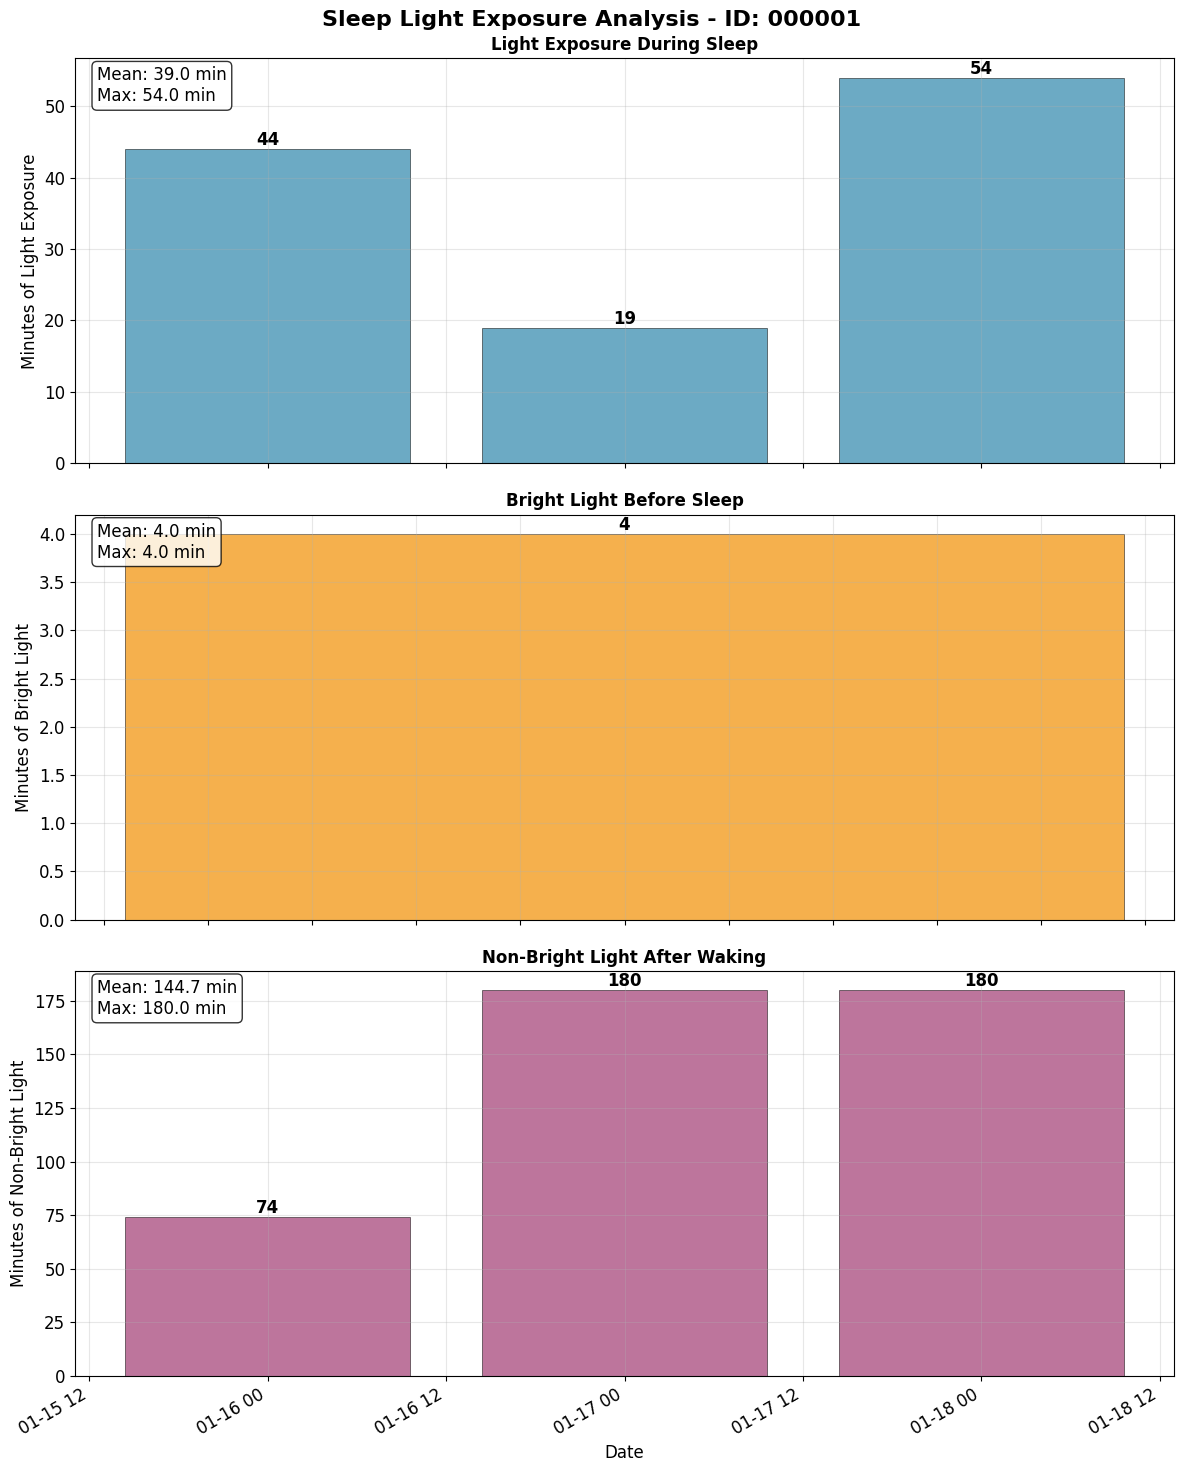


✅ Plot created successfully!


In [73]:
# 🎯 PLOT SLEEP LIGHT EXPOSURE FOR ID 000001
print("🎯 CREATING PLOT FOR ANALYSIS ID: 000001")
print("=" * 50)

# Create combined plot for ID 000001
fig = plot_sleep_light_exposure_metrics(db, '000001', plot_type='combined')

if fig:
    print("\n✅ Plot created successfully!")
else:
    print("\n💡 If no data was found, you may need to:")
    print("   1. Run a new analysis in the Streamlit app with ID 000001")
    print("   2. Make sure the analysis completes all steps including sleep_light_exposure")
    print("   3. Check that the data is properly saved to the database")

In [74]:
# 📊 INTERACTIVE DASHBOARD FOR ID 000001
print("📊 CREATING INTERACTIVE DASHBOARD FOR ID: 000001")
print("=" * 55)

# Create interactive dashboard
fig_dashboard = plot_sleep_light_exposure_metrics(db, '000001', plot_type='dashboard')

if fig_dashboard:
    print("✅ Interactive dashboard created successfully!")
    print("💡 The dashboard provides hover information and interactive features")

📊 CREATING INTERACTIVE DASHBOARD FOR ID: 000001
✅ Found sleep light exposure data for ID 000001


✅ Interactive dashboard created successfully!
💡 The dashboard provides hover information and interactive features


## 🤔 **Database Connection Explanation**

You're absolutely correct! The database **file** is named `Actigraph_record.db`. 

Here's what's happening with the `db` parameter:

1. **Database File**: `Actigraph_record.db` (the actual SQLite file on disk)
2. **Database Object**: `db` (a Python variable that holds an `ActigraphDB` instance)

In **Cell 5**, we created:
```python
db_path = "Actigraph_record.db"  # ← This is the database file name
db = ActigraphDB(db_path)        # ← This creates a Python object to interact with the file
```

So when we call:
```python
plot_sleep_light_exposure_metrics(db, '000001', 'combined')
```

We're passing the **database object** (`db`), not the filename. The `db` object knows how to connect to and read from the `Actigraph_record.db` file.

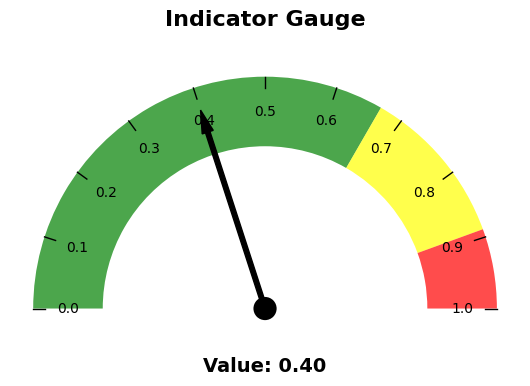

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

def create_speedometer(value=0.4, min_val=0, max_val=1, title='Speedometer'):
    """
    Creates and displays a speedometer-style gauge using Matplotlib.

    Args:
        value (float): The value to be displayed by the pointer.
        min_val (float): The minimum value of the gauge.
        max_val (float): The maximum value of the gauge.
        title (str): The title of the plot.
    """
    if not min_val <= value <= max_val:
        raise ValueError("Value must be between min_val and max_val.")

    # --- 1. Create the figure and axes ---
    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={'aspect': 'equal'})
    fig.canvas.manager.set_window_title('Speedometer Gauge')

    # --- 2. Define Gauge Properties ---
    # The gauge is a semi-circle, so we plot from 180 to 0 degrees
    start_angle = 180
    end_angle = 0
    radius = 1.0

    # Normalize the value to a 0-1 scale for angle calculation
    normalized_value = (value - min_val) / (max_val - min_val)

    # --- 3. Draw the colored arcs for the background ---
    # Green for low values, Yellow for medium, Red for high
    # These are Wedge patches. The angles are in degrees.
    green_wedge = Wedge(center=(0, 0), r=radius, theta1=60, theta2=180,
                          width=0.3, facecolor='green', alpha=0.7)
    yellow_wedge = Wedge(center=(0, 0), r=radius, theta1=20, theta2=60,
                           width=0.3, facecolor='yellow', alpha=0.7)
    red_wedge = Wedge(center=(0, 0), r=radius, theta1=0, theta2=20,
                        width=0.3, facecolor='red', alpha=0.7)

    ax.add_patch(green_wedge)
    ax.add_patch(yellow_wedge)
    ax.add_patch(red_wedge)

    # --- 4. Add ticks and labels ---
    num_ticks = 11
    tick_values = np.linspace(min_val, max_val, num_ticks)
    tick_angles = np.linspace(start_angle, end_angle, num_ticks)

    for val, angle_deg in zip(tick_values, tick_angles):
        angle_rad = np.deg2rad(angle_deg)
        # Outer point of the tick
        x1 = radius * np.cos(angle_rad)
        y1 = radius * np.sin(angle_rad)
        # Inner point of the tick
        x2 = (radius - 0.05) * np.cos(angle_rad)
        y2 = (radius - 0.05) * np.sin(angle_rad)
        # Label position
        lx = (radius - 0.15) * np.cos(angle_rad)
        ly = (radius - 0.15) * np.sin(angle_rad)

        ax.plot([x1, x2], [y1, y2], color='black', linewidth=1)
        ax.text(lx, ly, f'{val:.1f}', ha='center', va='center', fontsize=10)

    # --- 5. Draw the pointer (needle) ---
    pointer_angle_deg = start_angle - (normalized_value * 180)
    pointer_angle_rad = np.deg2rad(pointer_angle_deg)
    pointer_length = radius * 0.8

    pointer_x = pointer_length * np.cos(pointer_angle_rad)
    pointer_y = pointer_length * np.sin(pointer_angle_rad)

    # Use an arrow for the pointer
    ax.arrow(0, 0, pointer_x, pointer_y,
             width=0.02, head_width=0.05, head_length=0.1,
             fc='black', ec='black')

    # Add a circle at the center
    center_circle = Circle((0, 0), 0.05, facecolor='black')
    ax.add_patch(center_circle)

    # --- 6. Add the value text ---
    ax.text(0, -0.25, f'Value: {value:.2f}', fontsize=14,
            ha='center', va='center', weight='bold')

    # --- 7. Final plot adjustments ---
    ax.set_title(title, fontsize=16, weight='bold', pad=20)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.axis('off')  # Hide the x and y axes

    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    # Create a speedometer plot with the specified parameters
    create_speedometer(value=0.4, min_val=0, max_val=1, title="Indicator Gauge")


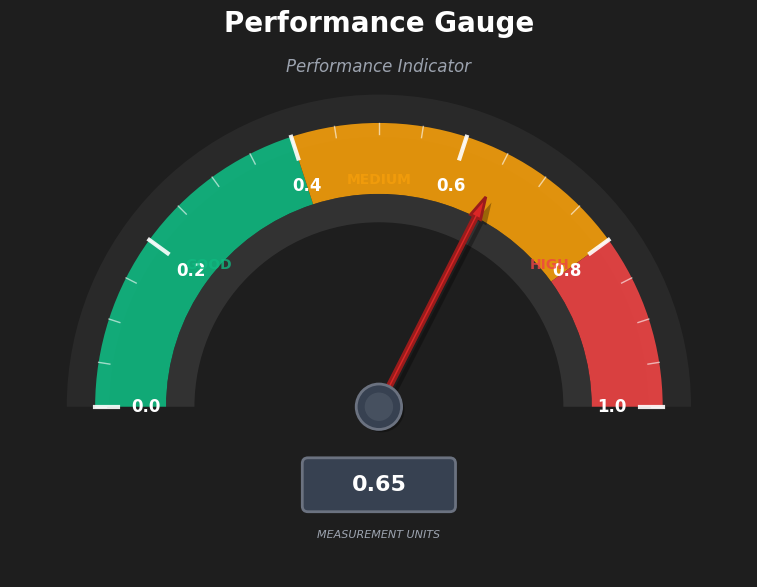

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle
import matplotlib.patches as patches

def create_speedometer(value=0.4, min_val=0, max_val=1, title='Speedometer'):
    """
    Creates and displays a visually enhanced speedometer-style gauge using Matplotlib.

    Args:
        value (float): The value to be displayed by the pointer.
        min_val (float): The minimum value of the gauge.
        max_val (float): The maximum value of the gauge.
        title (str): The title of the plot.
    """
    if not min_val <= value <= max_val:
        raise ValueError("Value must be between min_val and max_val.")

    # --- 1. Create the figure and axes with dark background ---
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'aspect': 'equal'})
    fig.patch.set_facecolor('#1e1e1e')  # Dark background
    ax.set_facecolor('#1e1e1e')

    # --- 2. Define Gauge Properties ---
    start_angle = 180
    end_angle = 0
    radius = 1.0
    normalized_value = (value - min_val) / (max_val - min_val)

    # --- 3. Enhanced colored arcs with gradients and modern colors ---
    # Outer ring for depth
    outer_ring = Wedge(center=(0, 0), r=radius + 0.1, theta1=0, theta2=180,
                       width=0.15, facecolor='#2c2c2c', alpha=0.8)
    ax.add_patch(outer_ring)
    
    # Main colored sections with modern colors
    green_wedge = Wedge(center=(0, 0), r=radius, theta1=108, theta2=180,
                        width=0.25, facecolor='#10b981', alpha=0.9)  # Modern green
    yellow_wedge = Wedge(center=(0, 0), r=radius, theta1=36, theta2=108,
                         width=0.25, facecolor='#f59e0b', alpha=0.9)  # Modern amber
    red_wedge = Wedge(center=(0, 0), r=radius, theta1=0, theta2=36,
                      width=0.25, facecolor='#ef4444', alpha=0.9)    # Modern red

    ax.add_patch(green_wedge)
    ax.add_patch(yellow_wedge)
    ax.add_patch(red_wedge)

    # Inner ring for depth
    inner_ring = Wedge(center=(0, 0), r=radius - 0.25, theta1=0, theta2=180,
                       width=0.1, facecolor='#404040', alpha=0.6)
    ax.add_patch(inner_ring)

    # --- 4. Enhanced ticks and labels ---
    num_major_ticks = 6
    num_minor_ticks = 21
    
    # Major ticks
    major_tick_values = np.linspace(min_val, max_val, num_major_ticks)
    major_tick_angles = np.linspace(start_angle, end_angle, num_major_ticks)
    
    for val, angle_deg in zip(major_tick_values, major_tick_angles):
        angle_rad = np.deg2rad(angle_deg)
        x1 = radius * np.cos(angle_rad)
        y1 = radius * np.sin(angle_rad)
        x2 = (radius - 0.08) * np.cos(angle_rad)
        y2 = (radius - 0.08) * np.sin(angle_rad)
        lx = (radius - 0.18) * np.cos(angle_rad)
        ly = (radius - 0.18) * np.sin(angle_rad)

        ax.plot([x1, x2], [y1, y2], color='white', linewidth=3, alpha=0.9)
        ax.text(lx, ly, f'{val:.1f}', ha='center', va='center', 
                fontsize=12, color='white', weight='bold')

    # Minor ticks
    minor_tick_angles = np.linspace(start_angle, end_angle, num_minor_ticks)
    for angle_deg in minor_tick_angles:
        angle_rad = np.deg2rad(angle_deg)
        x1 = radius * np.cos(angle_rad)
        y1 = radius * np.sin(angle_rad)
        x2 = (radius - 0.04) * np.cos(angle_rad)
        y2 = (radius - 0.04) * np.sin(angle_rad)
        
        ax.plot([x1, x2], [y1, y2], color='white', linewidth=1, alpha=0.6)

    # --- 5. Enhanced pointer with shadow effect ---
    pointer_angle_deg = start_angle - (normalized_value * 180)
    pointer_angle_rad = np.deg2rad(pointer_angle_deg)
    pointer_length = radius * 0.75

    pointer_x = pointer_length * np.cos(pointer_angle_rad)
    pointer_y = pointer_length * np.sin(pointer_angle_rad)

    # Shadow for pointer
    shadow_offset = 0.02
    ax.arrow(shadow_offset, -shadow_offset, pointer_x, pointer_y,
             width=0.015, head_width=0.04, head_length=0.08,
             fc='black', ec='none', alpha=0.3)

    # Main pointer with gradient effect
    ax.arrow(0, 0, pointer_x, pointer_y,
             width=0.015, head_width=0.04, head_length=0.08,
             fc='#dc2626', ec='#991b1b', linewidth=2)

    # --- 6. Enhanced center hub ---
    # Outer center circle (shadow)
    outer_center = Circle((0.01, -0.01), 0.08, facecolor='black', alpha=0.3)
    ax.add_patch(outer_center)
    
    # Main center circle with gradient effect
    center_circle = Circle((0, 0), 0.08, facecolor='#374151', ec='#6b7280', linewidth=2)
    ax.add_patch(center_circle)
    
    # Inner center highlight
    inner_center = Circle((0, 0), 0.05, facecolor='#4b5563', alpha=0.8)
    ax.add_patch(inner_center)

    # --- 7. Enhanced value display ---
    # Background for value display
    value_bg = patches.FancyBboxPatch((-0.25, -0.35), 0.5, 0.15,
                                      boxstyle="round,pad=0.02",
                                      facecolor='#374151', 
                                      edgecolor='#6b7280',
                                      linewidth=2)
    ax.add_patch(value_bg)
    
    ax.text(0, -0.275, f'{value:.2f}', fontsize=16,
            ha='center', va='center', weight='bold', color='white')
    
    # Unit label
    ax.text(0, -0.45, 'MEASUREMENT UNITS', fontsize=8,
            ha='center', va='center', color='#9ca3af', style='italic')

    # --- 8. Zone labels ---
    ax.text(-0.6, 0.5, 'GOOD', fontsize=10, ha='center', va='center', 
            color='#10b981', weight='bold', alpha=0.8)
    ax.text(0, 0.8, 'MEDIUM', fontsize=10, ha='center', va='center', 
            color='#f59e0b', weight='bold', alpha=0.8)
    ax.text(0.6, 0.5, 'HIGH', fontsize=10, ha='center', va='center', 
            color='#ef4444', weight='bold', alpha=0.8)

    # --- 9. Enhanced title ---
    ax.text(0, 1.35, title, fontsize=20, ha='center', va='center', 
            weight='bold', color='white')
    
    # Subtitle
    ax.text(0, 1.2, 'Performance Indicator', fontsize=12, ha='center', va='center', 
            color='#9ca3af', style='italic')

    # --- 10. Final adjustments ---
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.6, 1.4)
    ax.axis('off')

    plt.tight_layout()
    plt.show()
    
    return fig

if __name__ == '__main__':
    # Create an enhanced speedometer plot
    create_speedometer(value=0.65, min_val=0, max_val=1, title="Performance Gauge")

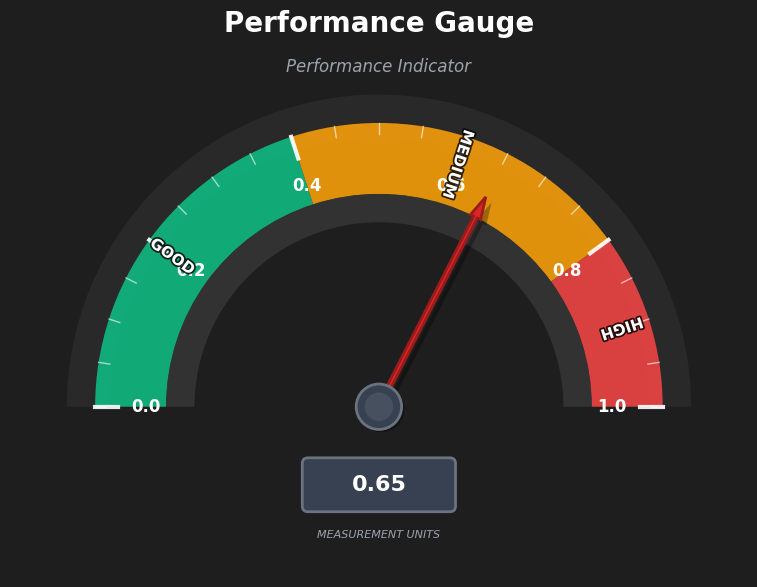

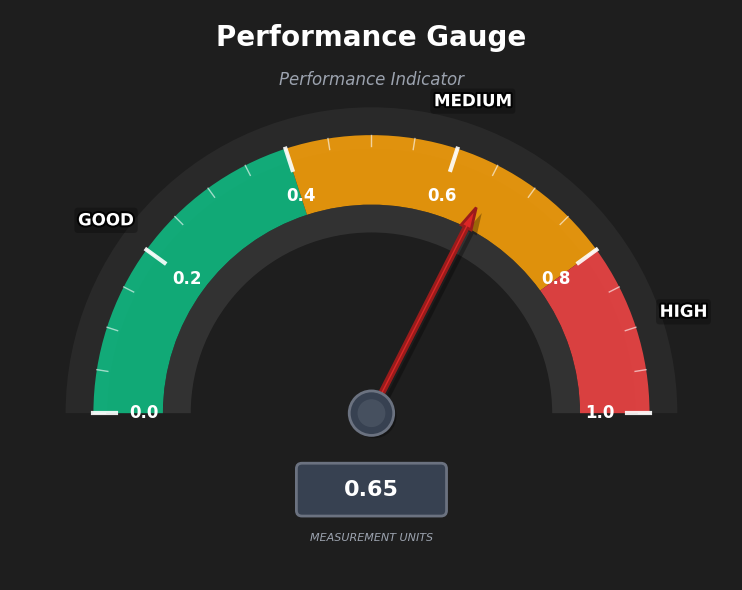

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle
import matplotlib.patches as patches
from matplotlib import patheffects  # for outlined text

def create_speedometer(value=0.4, min_val=0, max_val=1, title='Speedometer'):
    """
    Creates and displays a visually enhanced speedometer-style gauge using Matplotlib.

    Args:
        value (float): The value to be displayed by the pointer.
        min_val (float): The minimum value of the gauge.
        max_val (float): The maximum value of the gauge.
        title (str): The title of the plot.
    """
    if not min_val <= value <= max_val:
        raise ValueError("Value must be between min_val and max_val.")

    # --- 1. Create the figure and axes with dark background ---
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'aspect': 'equal'})
    fig.patch.set_facecolor('#1e1e1e')  # Dark background
    ax.set_facecolor('#1e1e1e')

    # --- 2. Define Gauge Properties ---
    start_angle = 180
    end_angle = 0
    radius = 1.0
    normalized_value = (value - min_val) / (max_val - min_val)

    # --- 3. Colored arcs + outer/inner rings ---
    # Outer ring for depth
    outer_ring = Wedge(center=(0, 0), r=radius + 0.1, theta1=0, theta2=180,
                       width=0.15, facecolor='#2c2c2c', alpha=0.8)
    ax.add_patch(outer_ring)
    
    # Main colored sections
    green_wedge = Wedge(center=(0, 0), r=radius, theta1=108, theta2=180,
                        width=0.25, facecolor='#10b981', alpha=0.9)  # GOOD
    yellow_wedge = Wedge(center=(0, 0), r=radius, theta1=36, theta2=108,
                         width=0.25, facecolor='#f59e0b', alpha=0.9)  # MEDIUM
    red_wedge = Wedge(center=(0, 0), r=radius, theta1=0, theta2=36,
                      width=0.25, facecolor='#ef4444', alpha=0.9)    # HIGH
    ax.add_patch(green_wedge)
    ax.add_patch(yellow_wedge)
    ax.add_patch(red_wedge)

    # Inner ring for depth
    inner_ring = Wedge(center=(0, 0), r=radius - 0.25, theta1=0, theta2=180,
                       width=0.1, facecolor='#404040', alpha=0.6)
    ax.add_patch(inner_ring)

    # --- 4. Ticks and labels ---
    num_major_ticks = 6
    num_minor_ticks = 21
    
    # Major ticks
    major_tick_values = np.linspace(min_val, max_val, num_major_ticks)
    major_tick_angles = np.linspace(start_angle, end_angle, num_major_ticks)
    for val, angle_deg in zip(major_tick_values, major_tick_angles):
        angle_rad = np.deg2rad(angle_deg)
        x1 = radius * np.cos(angle_rad)
        y1 = radius * np.sin(angle_rad)
        x2 = (radius - 0.08) * np.cos(angle_rad)
        y2 = (radius - 0.08) * np.sin(angle_rad)
        lx = (radius - 0.18) * np.cos(angle_rad)
        ly = (radius - 0.18) * np.sin(angle_rad)

        ax.plot([x1, x2], [y1, y2], color='white', linewidth=3, alpha=0.9)
        ax.text(lx, ly, f'{val:.1f}', ha='center', va='center', 
                fontsize=12, color='white', weight='bold')

    # Minor ticks
    minor_tick_angles = np.linspace(start_angle, end_angle, num_minor_ticks)
    for angle_deg in minor_tick_angles:
        angle_rad = np.deg2rad(angle_deg)
        x1 = radius * np.cos(angle_rad)
        y1 = radius * np.sin(angle_rad)
        x2 = (radius - 0.04) * np.cos(angle_rad)
        y2 = (radius - 0.04) * np.sin(angle_rad)
        ax.plot([x1, x2], [y1, y2], color='white', linewidth=1, alpha=0.6)

    # --- 5. Pointer with shadow ---
    pointer_angle_deg = start_angle - (normalized_value * 180)
    pointer_angle_rad = np.deg2rad(pointer_angle_deg)
    pointer_length = radius * 0.75

    pointer_x = pointer_length * np.cos(pointer_angle_rad)
    pointer_y = pointer_length * np.sin(pointer_angle_rad)

    # Shadow
    shadow_offset = 0.02
    ax.arrow(shadow_offset, -shadow_offset, pointer_x, pointer_y,
             width=0.015, head_width=0.04, head_length=0.08,
             fc='black', ec='none', alpha=0.3)

    # Main pointer
    ax.arrow(0, 0, pointer_x, pointer_y,
             width=0.015, head_width=0.04, head_length=0.08,
             fc='#dc2626', ec='#991b1b', linewidth=2)

    # --- 6. Center hub ---
    outer_center = Circle((0.01, -0.01), 0.08, facecolor='black', alpha=0.3)
    ax.add_patch(outer_center)
    center_circle = Circle((0, 0), 0.08, facecolor='#374151', ec='#6b7280', linewidth=2)
    ax.add_patch(center_circle)
    inner_center = Circle((0, 0), 0.05, facecolor='#4b5563', alpha=0.8)
    ax.add_patch(inner_center)

    # --- 7. Value display ---
    value_bg = patches.FancyBboxPatch((-0.25, -0.35), 0.5, 0.15,
                                      boxstyle="round,pad=0.02",
                                      facecolor='#374151', 
                                      edgecolor='#6b7280',
                                      linewidth=2)
    ax.add_patch(value_bg)
    ax.text(0, -0.275, f'{value:.2f}', fontsize=16,
            ha='center', va='center', weight='bold', color='white')
    ax.text(0, -0.45, 'MEASUREMENT UNITS', fontsize=8,
            ha='center', va='center', color='#9ca3af', style='italic')

    # --- 8. Zone labels (outside, horizontal, readable) ---
    # Mid-angles of wedges: GOOD(108–180), MEDIUM(36–108), HIGH(0–36)
    labels = [
        ("GOOD",   0.5 * (108 + 180)),
        ("MEDIUM", 0.5 * (36  + 108)),
        ("HIGH",   0.5 * (0   + 36)),
    ]
    # Place just beyond the outer ring (outer ring ends at r=radius+0.10)
    label_r = radius + 0.18

    for txt, ang in labels:
        ang_rad = np.deg2rad(ang)
        x = label_r * np.cos(ang_rad)
        y = label_r * np.sin(ang_rad)

        ax.text(
            x, y, txt,
            ha='center', va='center',
            fontsize=12, color='white', weight='bold',
            path_effects=[patheffects.withStroke(linewidth=3, foreground='black', alpha=0.85)],
            bbox=dict(boxstyle="round,pad=0.22", facecolor=(0, 0, 0, 0.25), edgecolor='none')
        )

    # --- 9. Title & subtitle ---
    ax.text(0, 1.35, title, fontsize=20, ha='center', va='center', 
            weight='bold', color='white')
    ax.text(0, 1.2, 'Performance Indicator', fontsize=12, ha='center', va='center', 
            color='#9ca3af', style='italic')

    # --- 10. Final adjustments ---
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.6, 1.45)  # a touch taller to accommodate outside labels
    ax.axis('off')

    plt.tight_layout()
    plt.show()
    return fig

if __name__ == '__main__':
    # Example usage
    create_speedometer(value=0.65, min_val=0, max_val=1, title="Performance Gauge")
